In [ ]:
import numpy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
na = np.newaxis

import sklearn,sklearn.datasets
import numpy,scipy,scipy.io
import time

import scipy.spatial.distance

# Coding Tricks

## algorithm

### SVD & Application

In [11]:
# 原始数据矩阵: 5个样本, 2个特征,shape  (5,2)
X = np.array([ 
    [2, 1],
    [3, 2],
    [4, 3],
    [5, 4],
    [6, 5]
], dtype=float)

# Step 1: 对每一列做中心化
X_mean = X.mean(axis=0) # (2, )
X_centered = X - X_mean #  (5,2) - (2,) => (5,2) - (1,2) => (5,2) - (5,2) 

print("mean:")
print(X_mean)
print("\nX.shape: ", X.shape)
print("\nX_mean.shape: ", X_mean.shape) # (2, )
print("\ncentered X:")
print(X_centered)

# Step 2: SVD
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

print("\nU:")
print(U)

print("\nSingular values S:")
print(S)

print("\nVt:")
print(Vt)

# step 3: 取前几个PC
k = 1
# Vt[:1] = 前 1 个主成分，Vt[:2] = 前 2 个主成分
# 每一行一个主成分
PCs = Vt[:k]      # shape: (k, d)

print("\nTop-k principal components row-wise:")
print(PCs)

# 每一列一个主成分
PCs_cols = Vt.T[:, :k]
print("\nTop-k principal components column-wise:")
print(PCs_cols)

# step 4: 把数据投影到前 k 个主成分上
# 公式：Z=X_centered @ V_k^T，假设V_k 是 row-wise 获得的
k = 1

Vk = Vt[:k]          # (k, d)
Z = X_centered @ Vk.T
print("\nProjected data,假设V_k 是 row-wise 获得的:")
print(Z)

# 公式：Z=X_centered @ V_k，假设V_k 是 column-wise 获得的
Vk = Vt.T[:, :k]          # shape (d, k)
Z = X_centered @ Vk       # shape (n, k)

print("\nProjected data,假设V_k 是 column-wise 获得的:")
print(Z)

# step 5: 从前 k 个主成分重建数据
# 公式：X_reconstructed=X_centered @ V_k + X_mean，假设V_k 是 row-wise 获得的
Vk = Vt[:k]          # (k, d)
Z = X_centered @ Vk.T
X_reconstructed = Z @ Vk + X_mean
print("Reconstructed X:")
print(X_reconstructed)

# 公式：X_reconstructed=X_centered V_k^T + X_mean，假设V_k 是 column-wise 获得的
Vk = Vt.T[:, :k]          # shape (d, k)
Z = X_centered @ Vk       # shape (n, k)

X_reconstructed = Z @ Vk.T + X_mean

print("Reconstructed X:")
print(X_reconstructed)

mean:
[4. 3.]

X.shape:  (5, 2)

X_mean.shape:  (2,)

centered X:
[[-2. -2.]
 [-1. -1.]
 [ 0.  0.]
 [ 1.  1.]
 [ 2.  2.]]

U:
[[-0.63245553  0.77459667]
 [-0.31622777 -0.25819889]
 [ 0.          0.        ]
 [ 0.31622777  0.25819889]
 [ 0.63245553  0.51639778]]

Singular values S:
[4.47213595e+00 3.99096226e-16]

Vt:
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]

Top-k principal components row-wise:
[[0.70710678 0.70710678]]

Top-k principal components column-wise:
[[0.70710678]
 [0.70710678]]

Projected data,假设V_k 是 row-wise 获得的:
[[-2.82842712]
 [-1.41421356]
 [ 0.        ]
 [ 1.41421356]
 [ 2.82842712]]

Projected data,假设V_k 是 column-wise 获得的:
[[-2.82842712]
 [-1.41421356]
 [ 0.        ]
 [ 1.41421356]
 [ 2.82842712]]
Reconstructed X:
[[2. 1.]
 [3. 2.]
 [4. 3.]
 [5. 4.]
 [6. 5.]]
Reconstructed X:
[[2. 1.]
 [3. 2.]
 [4. 3.]
 [5. 4.]
 [6. 5.]]


### Power Interation

## syntax

broadcasting

In [ ]:
# (N,1) - (1,M) => (N,M) - (N-M) = (N,M)

np.nexaxis

In [29]:
# numpy.newaxis 是一个特殊对象（本质是 None）
# 用来增加数组维度（扩展 shape）
# na = np.newaxis
# a[:, na]

a = np.array([1,2,3,4])
print(a.shape)
print(a)
b = a[:,np.newaxis]
print(b.shape)
print(b)
c = a[np.newaxis, :]
print(c.shape)
print(c)

(4,)
[1 2 3 4]
(4, 1)
[[1]
 [2]
 [3]
 [4]]
(1, 4)
[[1 2 3 4]]


shape (2,),(2,1),(1,2)

In [42]:
a = np.array([1, 2])
print(a.shape)   # (2,),没有“行/列”概念,只是一个长度为2的数组,NumPy 会在运算时自动决定方向

b = np.array([[1],
              [2]])
print(b.shape)   # (2,1)

c = np.array([[1,2]]) # (1,2)
print(c.shape)


# numpy 如何在运算中自动决定方向，例子
a = np.array([1, 2, 3])      # shape (3,)
M = np.array([[1,2],
              [3,4],
              [5,6]])
# (3, ) @ (3,2) => (1,3) @ (3,2)
a @ M

a = np.array([1, 2])  
# (3,2) @ (2,) = > (3,2) @ (2,1)
M @ a

(2,)
(2, 1)
(1, 2)


array([ 5, 11, 17])

|A|: 求determinant，|x|: 求绝对值

In [9]:
A = np.array([[1.0,0],[0,0.5]])
det = np.linalg.det(A)
print(det)

0.5


$A^{-1}$

In [10]:
A = np.array([[1.0,0],[0,0.5]])
inv_A = np.linalg.inv(A)
print(inv_A)

[[1. 0.]
 [0. 2.]]


np.stack(arrays, axis=0, out=None)

In [16]:
# （a,b), or [a,b], same effect
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
stacked0 = np.stack((a, b), axis=0)
stacked1 = np.stack((a, b), axis=1)
print(stacked0, "\n",stacked1)

stacked1 = np.stack([a, b], axis=1)
print(stacked1)

[[1 2 3]
 [4 5 6]] 
 [[1 4]
 [2 5]
 [3 6]]


np.ravel()

In [23]:
# difference bewteen flatten and ravel:
#          np.ravel().                np.flatten()
# 内存效率. 更高（不产生新数据）.          较低（复制一份新数据）
# 修改后果. 修改返回的数组会影响原数组.     修改返回的数组不会影响原数组

arr = np.array([[1, 2, 3], 
                [4, 5, 6]])

flat_arr = np.ravel(arr)
print(flat_arr)

# 按行 (C-style)
print(np.ravel(arr, order='C'))

# 按列 (Fortran-style)
print(np.ravel(arr, order='F'))

print("origin:\n",arr)
flat_arr[0] = 100
print("after modify:\n",arr)

[1 2 3 4 5 6]
[1 2 3 4 5 6]
[1 4 2 5 3 6]
origin:
 [[1 2 3]
 [4 5 6]]
after modify:
 [[100   2   3]
 [  4   5   6]]


meshgrid,自己画个图就理解了

In [3]:
# 1. Define the 1D coordinate arrays
x_coords = np.array([1, 2, 3])
y_coords = np.array([10, 20])

# 2. Create the meshgrid
X, Y = np.meshgrid(x_coords, y_coords)

# 3. Perform an operation on the grid
Z = X + Y

print("X grid:\n", X)
print("\nY grid:\n", Y)
print("\nZ (X + Y):\n", Z)

X grid:
 [[1 2 3]
 [1 2 3]]

Y grid:
 [[10 10 10]
 [20 20 20]]

Z (X + Y):
 [[11 12 13]
 [21 22 23]]


np.flatten()

In [10]:
a = np.array([[1,2,3],[4,5,6]])
print(a)
a_flatten = a.flatten()
print(a_flatten)

[[1 2 3]
 [4 5 6]]
[1 2 3 4 5 6]


zip()

In [12]:
a = [1,2,3]
b = [4,5,6]
c = zip(a,b)
print(c)

for x,y in c:
    print((x,y))

(1, 4)
(2, 5)
(3, 6)


list()

In [18]:
a = [1,2,3]
aa = list(a)
print(aa)
print(type(a))
print(type(aa))

a = [1,2,3]
b = [4,5,6]
c = zip(a,b)
print(type(c))
cc = list(c)
print(type(cc))
print(cc)

[1, 2, 3]
<class 'list'>
<class 'list'>
<class 'zip'>
<class 'list'>
[(1, 4), (2, 5), (3, 6)]


np.arange()

In [22]:
# 1e-9 的作用是，使得结果保留10
a = np.arange(0,10+1e-9,2)
print(a)

[ 0.  2.  4.  6.  8. 10.]


# 1 Baysian Decision

## Gaussian Distribution

###
$f(x,y) = \sqrt{x^2 + y^2}$ 

In [36]:
X = np.ones(3)
Y = np.ones(3)
print(X)
print(X**X)
print(X**X + Y**Y)
f = (X**X + Y**Y)**0.5
print(f)

[1. 1. 1.]
[1. 1. 1.]
[2. 2. 2.]
[1.41421356 1.41421356 1.41421356]


(81, 81) (81, 81)
(81, 81)


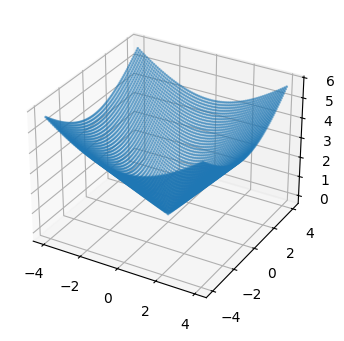

In [38]:
R = np.arange(-4,4+1e-9,0.1)
X,Y = np.meshgrid(R,R)
print(X.shape,Y.shape)
F = (X**2+Y**2)**.5
print(F.shape)
fig = plt.figure(figsize=(5,4))
ax = plt.axes(projection='3d')
ax.scatter(X,Y,F,s=1,alpha=0.5)

###
$
p(x,y) = \frac{1}{2\pi}e^{-0.5 (x^2+y^2)}.
$

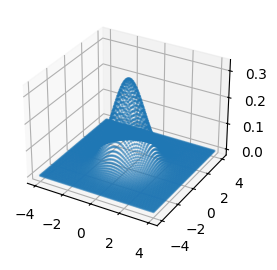

In [9]:
R = np.arange(-4,4+1e-9,0.1)
X,Y = np.meshgrid(R,R)
p = 1/np.pi * np.exp(-0.5*(X**2 + Y**2))

fig = plt.figure(figsize=(5,3))
ax = plt.axes(projection='3d')
ax.scatter(X,Y,p,s=1,alpha=0.5)

###
$
P(x,y) = \frac1Z e^{-0.5 (x^2+y^2)} \qquad \text{with} \quad Z = \sum_{x,y} e^{-0.5 (x^2+y^2)}
$

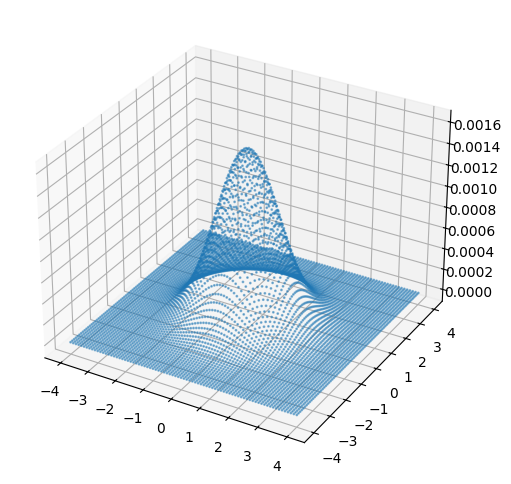

In [ ]:
# distribution P(x,y)
R = np.arange(-4,4+1e-9,0.1)
X,Y = np.meshgrid(R,R)
cond = (X**2 + Y**2)**0.5 # <class 'numpy.ndarray'>

Z = np.sum(np.exp(-0.5*(X**2+Y**2)))

P = (1/Z ) * np.exp(-0.5*(X**2+Y**2))

fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection='3d')
ax.scatter(X,Y,P,s=1,alpha=0.5)

### 
$Q(x,y) = P((x,y) | \sqrt{x^2+y^2} \geq 1)$

$P(x,y) = \frac1Z e^{-0.5 (x^2+y^2)} \qquad \text{with} \quad Z = \sum_{x,y} e^{-0.5 (x^2+y^2)}$

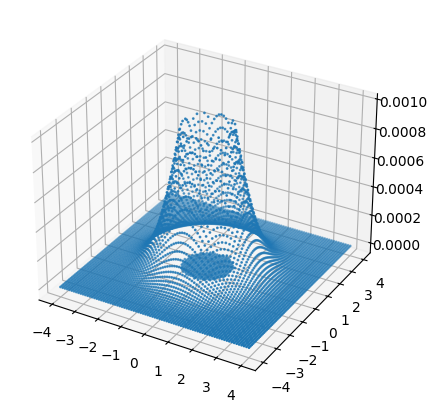

In [ ]:
# conditioned distribution Q(x,y)
R = np.arange(-4,4+1e-9,0.1)
X,Y = np.meshgrid(R,R)
r_squre = (X**2 + Y**2)
cond_true = r_squre >= 1      #  (81, 81)  
tmp = np.exp(-0.5* r_squre)
Q = (tmp / np.sum(tmp)) * cond_true

fig = plt.figure(figsize=(5,5))
ax = plt.axes(projection='3d')
ax.scatter(X,Y,Q,s=1)


Marginalize the conditioned distribution $Q(x,y)$ over $y$, and plot the resulting distribution $Q(x)$

$Q(x) = \sum_{y} Q(x,y)$

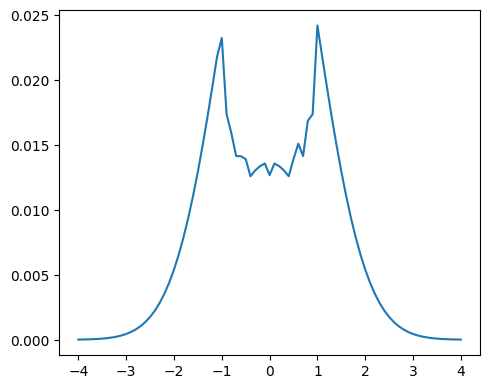

In [ ]:
# marginalize over y 的意思是 把 y 消掉，
# 只保留  x 的概率分布
# 把二维分布降成一维分布
# 具体操作是对 y 求和（因为你是离散网格）

Q_x = np.sum(Q,axis=0)
fig = plt.figure(figsize=(5,4))
plt.plot(R,Q_x)
plt.tight_layout()
plt.show()


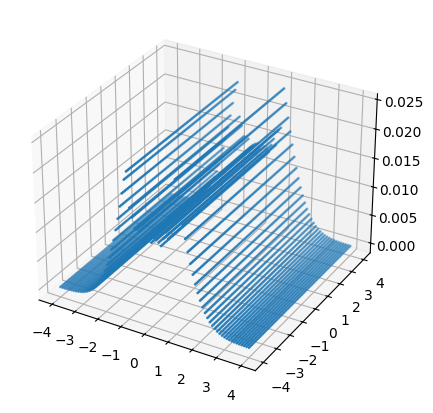

In [20]:
fig = plt.figure(figsize=(5,5))
ax = plt.axes(projection='3d')
ax.scatter(X,Y,Q_x,s=1)

## Bayesian Classification

##
$p(\boldsymbol{x}|\omega_1)$ , $p(\boldsymbol{x}|\omega_2)$ 

Mahalanobis distance

$$
D_M(\mathbf{x}) = \sqrt{(\mathbf{x} - \mu)^T \Sigma^{-1} (\mathbf{x} - \mu)}
$$

Mahalanobis distance squared
$$
D_M^2(\mathbf{x}) = (\mathbf{x} - \mu)^T \Sigma^{-1} (\mathbf{x} - \mu)
$$

Multivariate Gaussian
$$
p(\mathbf{x} \mid \omega_k) =
\frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}}
\exp\left(
-\frac{1}{2} (\mathbf{x} - \mu_k)^T \Sigma^{-1} (\mathbf{x} - \mu_k)
\right)
$$

here d=2

**From these distributions, compute the total probability distribution $P(\boldsymbol{x}) = \sum_{c \in \{1,2\}} P(\boldsymbol{x} | \omega_c) \cdot P(\omega_c)$, and plot it.**

**Compute and plot the class posterior probabilities $P(\omega_1|\boldsymbol{x})$ and $P(\omega_2|\boldsymbol{x})$, and print the Bayes error rate for the discretized case.**

对于每个 grid 点 $\mathbf{x}$，最优分类器选：$\arg \max_{c} P(\omega_c \mid \mathbf{x})$ 

那么这个点的错误概率是：$\min \big( P(\omega_1 \mid \mathbf{x}), P(\omega_2 \mid \mathbf{x}) \big)$

In [121]:
class BayesianClassifier2D:
    def __init__(self,X,Y,mu1,mu2,p1,p2,sigma):
        self.X = X
        self.Y = Y
        self.mu1 = mu1
        self.mu2 = mu2
        self.p1 = p1 #p(w1)
        self.p2 = p2 #p(w2)
        self.sigma = sigma
        self.inv_sigma = np.linalg.inv(sigma)
        self.det_sigma = np.linalg.det(sigma)

    def multivariant_gaussian(self,mu):
        # X,Y: (81,81)
        # wrong demention match
        # (X - mu1).transpose @ np.linalg.inv(sigma) @ (X-mu1)
        # (X - mu1): operands could not be broadcast together with shapes (81,81) (2,) 

        # ----- adjust demention -----
        points = np.stack([self.X.ravel(), self.Y.ravel()], axis=1)  # (6561,2)
        diff = points - mu # (6561,2) - (2,) = (6561,2) - (1,2)= (6561,2) -（6561，2）
        mahalanobis = np.sum(diff @ self.inv_sigma * diff, axis=1)  # (6561,)， # (6561,2) @ (2,2) => (6561,2)
        mahalanobis = mahalanobis.reshape(self.X.shape) #(81,81)
        P_raw = (1 / (2 * np.pi * np.sqrt(self.det_sigma))) * np.exp(-0.5 * mahalanobis) # (81,81)，这是 grid 上的连续密度值
        P = P_raw / np.sum(P_raw) # 做归一化，np.sum(P1) 应该接近 1

        return P
    
    def total_distribution(self,p_x_w1,p_x_w2):  
        p_total = p_x_w1 * self.p1 + p_x_w2 * self.p2
        return p_total 

    def postterior(self,p_x_w,p_w,p_total):
        p_w_x = (p_x_w*p_w)/p_total
        return p_w_x

    def error_rate(self,p_w1_x1,p_w1_x2):
        return(np.minimum(p_w1_x1,p_w1_x2))
    
    def set_sigma(self,sigma):
        self.sigma = sigma
        self.inv_sigma = np.linalg.inv(sigma)
        self.det_sigma = np.linalg.det(sigma)
    
    

In [116]:
class PlotPretty():
    def __init__(self):
        pass

    def plot_2d_gaussian_distribution(self,X,Y,P_w1,P_w2,p1,p2,title=None):
        # posterior1 = P_w1 * p1
        # posterior2 = P_w2 * p2
        # boundary = posterior1 - posterior2

        boundary = P_w1*p1 - P_w2*p2
        fig = plt.figure(figsize=(6,6))
        ax = fig.add_subplot(111, projection='3d')

        # class 1
        ax.scatter(X, Y, P_w1, s=0.5, alpha=0.3, color='green')

        # class 2
        ax.scatter(X, Y, P_w2, s=0.5, alpha=0.5, color='red')
        
        ax.contour(
            X, Y, boundary,
            levels=[0],          # boundary = 0
            colors='black',
            linewidths=2
        )

        ax.set_title(title)

        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('probability')

        plt.show()
    
    def plot_one_gaussian_distribution(self,X,Y,P,title=None):
        plt.figure(figsize=(6,6))
        ax = plt.axes(projection='3d')
        ax.scatter(X,Y,P,s=0.5,alpha=0.5)
        ax.set_title(title)
        plt.show()
    
    def plot_3_gaussian_distribution(self,P_w1,P_w2,error_rate,title=None):
            fig = plt.figure(figsize=(6,6))
            ax = fig.add_subplot(111, projection='3d')


            surf1 = ax.plot_surface(X, Y, P_w1, color='green', alpha=0.3)
            surf2 = ax.plot_surface(X, Y, P_w2, color='red', alpha=0.3)
            
            surf3 = ax.plot_surface(X, Y, error_rate, color='blue', alpha=0.4)

            ax.set_title(title)

            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.set_zlabel('probability')

            plt.show()
        


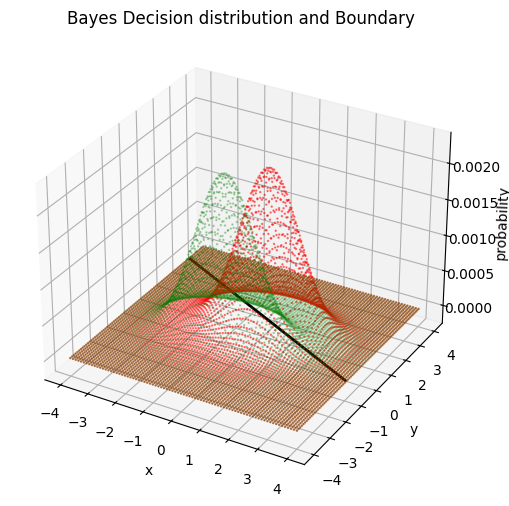

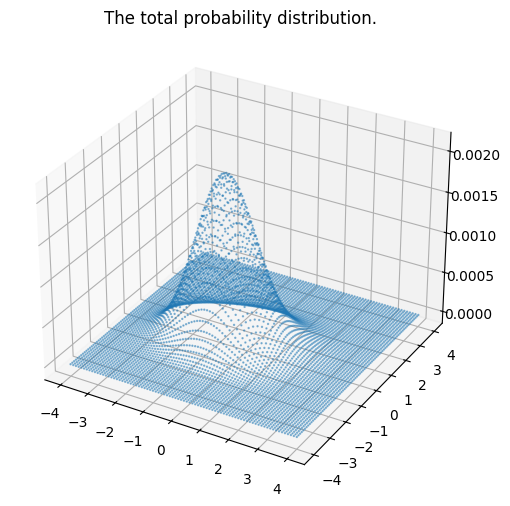

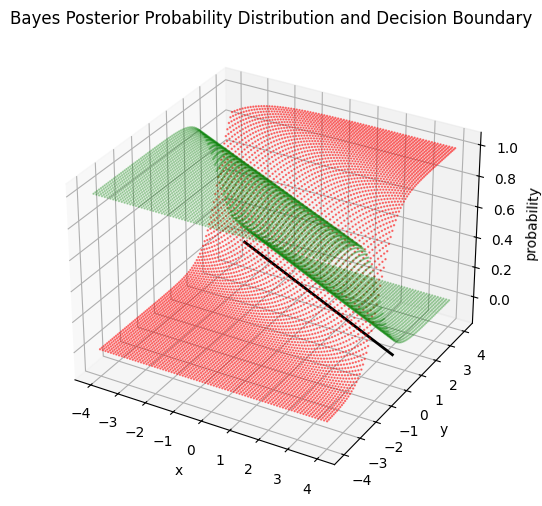

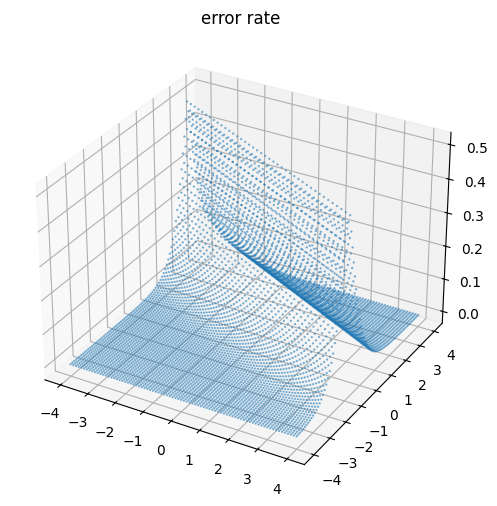

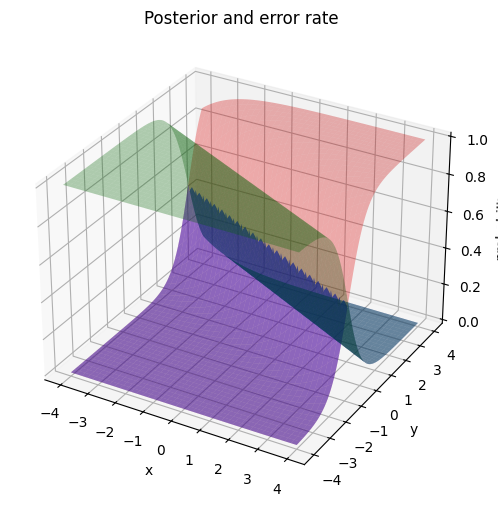

In [117]:
R = np.arange(-4,4+1e-9,0.1)
X,Y = np.meshgrid(R,R)
mu1 = np.array([-0.5,-0.5])         #(2,2)
mu2 = np.array([0.5,0.5])
sigma = np.array([[1.0,0],[0,0.5]])  #(2,2)
p1 = 0.9
p2 = 0.1

Bayes2D = BayesianClassifier2D(X,Y,mu1,mu2,p1,p2,sigma)
P_x_w1 = Bayes2D.multivariant_gaussian(mu1)
P_x_w2 = Bayes2D.multivariant_gaussian(mu2)
P_total = Bayes2D.total_distribution(P_x_w1,P_x_w2)
P_w1_x = Bayes2D.postterior(P_x_w1,p1,P_total)
P_w2_x = Bayes2D.postterior(P_x_w2,p2,P_total)
error_rate = Bayes2D.error_rate(P_w1_x,P_w2_x)

plotter = PlotPretty()
plotter.plot_2d_gaussian_distribution(X,Y,P_x_w1,P_x_w2,p1,p2,"Bayes Decision distribution and Boundary")
plotter.plot_one_gaussian_distribution(X,Y,P_total,"The total probability distribution.")
plotter.plot_2d_gaussian_distribution(X,Y,P_w1_x,P_w2_x,p1,p2,"Bayes Posterior Probability Distribution and Decision Boundary")
plotter.plot_one_gaussian_distribution(X,Y,error_rate,"error rate")
plotter.plot_3_gaussian_distribution(P_w1_x,P_w2_x,error_rate,"Posterior and error rate")

## Reducing the variance

Suppose that the data generating distribution for the second class changes to produce samples much closer to the mean. This variance reduction for the second class is implemented by keeping the first covariance the same (i.e. $\Sigma_1 = \Sigma$) and dividing the second covariance matrix by 4 (i.e. $\Sigma_2 = \Sigma/4$). For this new set of parameters, we can perform the same analysis as in Exercise 2.

**Plot the new class posterior probabilities $P(\omega_1|\boldsymbol{x})$ and $P(\omega_2|\boldsymbol{x})$ associated to the new covariance matrices, and print the new Bayes error rate.**

Intuition tells us that by variance reduction and resulting concentration of generated data for class 2 in a smaller region of the input space, it should be easier to predict class 2 with certainty at this location. Paradoxally, in this new "dense" setting, we observe that class 2 does not reach full certainty anywhere in the input space, whereas it did in the previous exercise.

**Explain this paradox.**


215.44188969856936


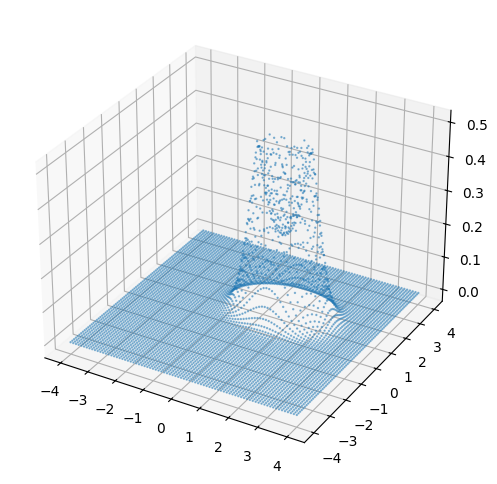

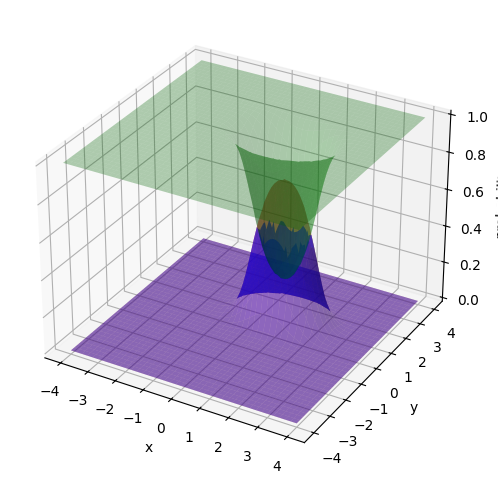

In [ ]:
reduce_variable = BayesianClassifier2D(X,Y,mu1,mu2,p1,p2,sigma)
p_x1_w1 = reduce_variable.multivariant_gaussian(mu1)

reduce_variable.set_sigma(sigma/4)

p_x2_w2 = reduce_variable.multivariant_gaussian(mu2)
p_total = reduce_variable.total_distribution(p_x1_w1,p_x2_w2)

P_w1_x1 = reduce_variable.postterior(p_x1_w1,p1,p_total)
P_w2_x2 = reduce_variable.postterior(p_x2_w2,p2,p_total)

error_rate = reduce_variable.error_rate(P_w1_x1,P_w2_x2)

plotter.plot_one_gaussian_distribution(X,Y,error_rate)
plotter.plot_3_gaussian_distribution(P_w1_x1,P_w2_x2,error_rate)

# 2 Parameter Estimation

## Maximum Likelihood Parameter Estimation

In this first exercise, we would like to use the maximum-likelihood method to estimate the best parameter of a data density model $p(x|\theta)$ with respect to some dataset $\mathcal{D} = (x_1,\dots,x_N)$, and use that approach to build a classifier. Assuming the data is generated independently and identically distributed (iid.), the dataset likelihood is given by
$$
p(\mathcal{D}|\theta) = \prod_{k=1}^N p(x_k|\theta)
$$
and the maximum likelihood solutionss is then computed as
\begin{align*}
\hat{\theta}
&= \text{arg}\max_\theta ~ p(\mathcal{D}|\theta)\\
&= \text{arg}\max_\theta ~ \log p(\mathcal{D}|\theta)
\end{align*}
where the log term can also be expressed as a sum, i.e.
$$
\log p(\mathcal{D}|\theta) = \sum_{k=1}^N \log p(x_k|\theta).
$$
As a first step, we load some useful libraries for numerical computations and plotting.

We now consider the univariate data density model 

$$
p(x|\theta) = \frac1\pi \frac{1}{1+(x-\theta)^2}
$$

also known as the Cauchy distribution with fixed parameter $\gamma=1$, and with parameter $\theta$ unknown. Compared to the Gaussian distribution, the Cauchy distribution is heavy-tailed, and this can be useful to handle the presence of outliers in the data generation process. The probability density function is implemented below.

Implement a function that takes a dataset $\mathcal{D}$ as input (given as one-dimensional array of numbers) and a list of candidate parameters $\theta$ (also given as a one-dimensional array), and returns a one-dimensional array containing the log-likelihood w.r.t. the dataset $\mathcal{D}$ for each parameter $\theta$.

In [85]:
def pdf(X,THETA):
    return (1.0 / np.pi) * (1.0 / (1+(X-THETA)**2))

def ll(D,THETA):
    # broadcasting
    D = D[:, np.newaxis] # (N,1)
    THETA = THETA[np.newaxis, :] #(1,M)
    likelihood = pdf(D, THETA)     # shape: (N,M)
    log_likelihood = np.log(likelihood)  # shape: (N,M)
    return np.sum(log_likelihood, axis=0)  # shape: (M,), 注意axisx


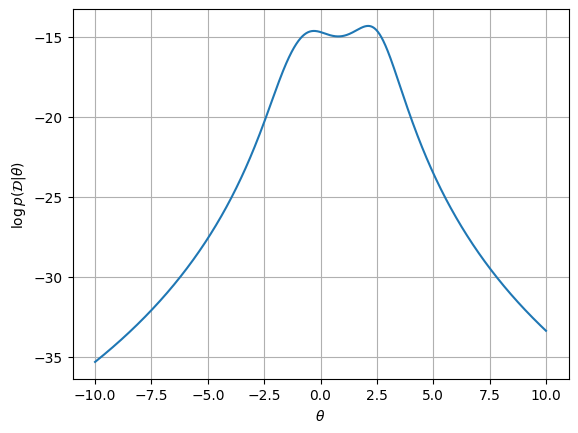

We observe that the likelihood has two peaks: one around theta=-0.5 
and one around theta=2.
However, the highest peak is the second one,
hence, the second peak is retained as a maximum likelihood solution.


In [86]:
# 验证代码
D = np.array([ 2.803, -1.563, -0.853,  2.212, -0.334,  2.503])

THETA = np.linspace(-10,10,1001)

plt.grid(True)
plt.plot(THETA,ll(D,THETA))
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\log p(\mathcal{D}|\theta)$')
plt.show()

print("We observe that the likelihood has two peaks: one around theta=-0.5 "\
"\nand one around theta=2."\
"\nHowever, the highest peak is the second one,"\
"\nhence, the second peak is retained as a maximum likelihood solution.")

### Building a Classifier

We now would like to use the maximum likelihood technique to build a classifier. We consider a labeled dataset where the data associated to the two classes are given by:

D1 = np.array([ 2.803, -1.563, -0.853,  2.212, -0.334,  2.503])

D2 = np.array([-4.510, -3.316, -3.050, -3.108, -2.315])

To be able to classify new data points, we consider the discriminant function

$$
g(x) = \log P(x|\hat{\theta}_1) -  \log P(x|\hat{\theta}_2) + \log P(\omega_1) - \log P(\omega_2)
$$

were the first two terms can be computed based on our maximum likelihood estimates, and where the last two terms are the prior probabilities. The function $g(x)$ produces the decision $\omega_1$ if $g(x) > 0$ and $\omega_2$ if $g(x) < 0$. We would like to implement a maximum-likelihood based classifier.

**Tasks:**

* **Implement the function `fit` that receives as input a vector of candidate parameters $\theta$ and the dataset associated to each class, and produces the maximum likelihood parameter estimates.** *(Hint: from your function `fit`, you can call the function `ll` you have previously implemented.)*


* **Implement the function `predict` that takes as input the prior probability for each class and a vector of points X on which to evaluate the discriminant function, and that outputs a vector containing the value of $g$ for each point in X.**

In [89]:
def pdf(X,THETA):
    return (1.0 / np.pi) * (1.0 / (1+(X-THETA)**2))

def ll(D,THETA):
    # broadcasting
    D = D[:, np.newaxis] # (N,1)
    THETA = THETA[np.newaxis, :] #(1,M)
    likelihood = pdf(D, THETA)     # shape: (N,M)
    log_likelihood = np.log(likelihood)  # shape: (N,M)
    return np.sum(log_likelihood, axis=0)  # shape: (M,), 注意axisx

class MLClassifier:
    
    def fit(self,THETA,D1,D2):
        # THETA.shape: (M,1), [t1,t2,t3,...t_n]
        ll_D1 = ll(D1,THETA)
        ll_D2 = ll(D2,THETA)

        self.theta1 = THETA[np.argmax(ll_D1)]
        self.theta2 = THETA[np.argmax(ll_D2)]

    def predict(self,X,p1,p2):
        # p1 = p(ω1), p2 = p(ω2)
        g = (
            np.log(pdf(X, self.theta1))
            - np.log(pdf(X, self.theta2))
            + np.log(p1)
            - np.log(p2)
        )

        return g


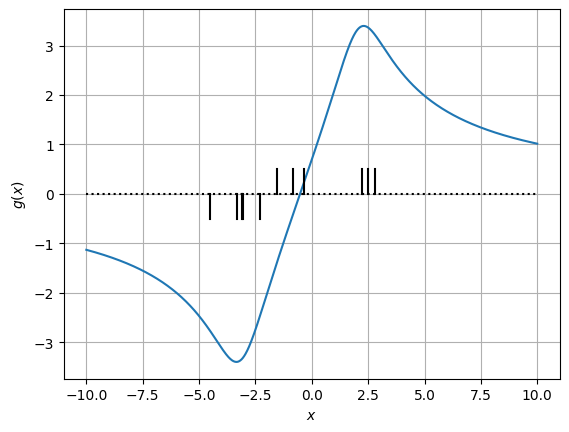

In [34]:
D1 = np.array([ 2.803, -1.563, -0.853,  2.212, -0.334,  2.503])
D2 = np.array([-4.510, -3.316, -3.050, -3.108, -2.315])

X = np.linspace(-10,10,1001)

plt.grid(True)

mlcl = MLClassifier()
mlcl.fit(THETA,D1,D2)

plt.plot(X,mlcl.predict(X,0.5,0.5))
plt.plot(X,0*X,color='black',ls='dotted')

plt.xlabel(r'$x$')
plt.ylabel(r'$g(x)$')

for d1 in D1: plt.plot([d1,d1],[0,+0.5],color='black')
for d2 in D2: plt.plot([d2,d2],[0,-0.5],color='black')

### 结果解释

Here, we observe that the model essentially learns a threshold classifier with threshold approximately $-0.5$. However, we note that the threshold seems to be too high to properly classify the data. One reason for this is the fact that maximum likelihood estimate retains only the best parameter. Here, the model for the first class focuses mainly on the peak at $x=2$ and treat examples $x < 0$ as outliers, without considering the possibility that the peak at $\theta=2$ might actually be the outlier.

> 这个分类器到底在做什么

前面做的是：

- 对第一类数据 `D1`，找一个最优的 $\hat{\theta}_1$
- 对第二类数据 `D2`，找一个最优的 $\hat{\theta}_2$

然后用：

$$
g(x) = \log p(x \mid \hat{\theta}_1) - \log p(x \mid \hat{\theta}_2) + \log p(\omega_1) - \log p(\omega_2)
$$

来分类。

若：

- $g(x) > 0$，判成 $\omega_1$
- $g(x) < 0$，判成 $\omega_2$

图里蓝线就是 $g(x)$，黑色虚线是 $g(x)=0$。

所以：

- 蓝线在 0 上面：预测为 class 1  
- 蓝线在 0 下面：预测为 class 2  

---

> “threshold approximately −0.5” 意思

因为分类规则是看 $g(x)$ 的正负，所以真正的分类边界是：

$$
g(x) = 0
$$

从图上看，蓝线和横轴的交点大约在 $x \approx -0.5$。

模型学出来的规则大致是：

- $x > -0.5$ 时，更倾向判为 $\omega_1$
- $x < -0.5$ 时，更倾向判为 $\omega_2$

这就是“模型本质上学到了一个 threshold classifier”。

---

> 为什 threshold “too high”

数据为：

```python
D1 = [ 2.803, -1.563, -0.853,  2.212, -0.334,  2.503]
D2 = [-4.510, -3.316, -3.050, -3.108, -2.315]
```

- $D_2$ 基本都在 $[-4.5, -2.3]$ 附近，很集中地在左边  
- $D_1$ 里有两部分：
  - 一部分在 $[2, 3]$ 附近  
  - 另一部分在 $[-1.5, -0.85, -0.33]$ 附近  

也就是说，$D_1$ 实际不是一个很单纯的“单峰”分布，它更像：

- 主体在正数附近  
- 但也有几个落在负数附近的点  

而学出来的边界 $x \approx -0.5$ 会把：

- $-1.563$
- $-0.853$

这些本来属于 $D_1$ 的点判成 $D_2$。

所以这个边界对当前数据来说偏右了，不够好。


> 真正问题

- 对于 class 1，你最后只保留了一个参数 $\hat{\theta}_1$
- 这个参数代表“这类数据最像哪个 Cauchy 分布中心”

但$D1$并不真的像“一个简单的单峰 Cauchy 分布”。

---

> why $D1$ 会被拟合成大约 $\theta = 2$

$D1$：

$$
[2.803,\ -1.563,\ -0.853,\ 2.212,\ -0.334,\ 2.503]
$$

其中有 3 个点明显靠近 $2 \sim 3$：

- 2.803  
- 2.212  
- 2.503  

这些点形成一个比较明显的“峰”。

于是 maximum likelihood 可能会认为：

最合适的 $\theta_1$ 大概就在 2 附近

这样一来，模型会把 class 1 看成一个“以 2 为中心的 Cauchy 分布”。

---

> 那负数那几个 $D1$ 点怎么办


- 模型更关注 $D1$ 中正数那一团  
- 把 $D1$ 中负数那几个点，当成“离群点”或者“少数异常值”  

但问题在于： 也许真实情况不是“负数点是 outliers”，而是“正数那团才是 outliers”. 当前这个模型没有能力判断哪一团才是真正代表 class 1 的主体。

---

> 本质限制：每个类只用一个参数，表达能力太弱

这里每一类的模型是：

$$
p(x|\theta) = \frac{1}{\pi(1+(x-\theta)^2)}
$$

你只估计一个 $\theta$，也就是只允许：

- 一个中心  
- 一个单峰分布  

但 $D1$ 看起来更像有两团数据。

所以这个模型太简单，无法表达：

- 一类数据内部可能有多个 cluster  
- 一类数据并不一定是单峰的  

这才是这段话真正指出的问题。

## Bayes Parameter Estimation

pdf is defined as:

$$
p(x|\theta) = \frac1\pi \frac{1}{1+(x-\theta)^2}
$$

Let us now bypass the computation of a maximum likelihood estimate of parameters and adopt instead a full Bayesian approach. We will consider the same data density model and datasets as in the maximum likelihood exercise but we include now a prior distribution over the parameters. Specifically, we set for both classes the prior distribution:

the prior distribution

$$
p(\theta) = \frac{1}{10\pi} \frac{1}{1+(\theta/10)^2}
$$

Given a dataset $\mathcal{D}$, the posterior distribution for the unknown parameter $\theta$ can then be obtained from the Bayes rule:

the posterior distribution

$$
p(\theta | \mathcal{D}) = \frac{p(\mathcal{D} | \theta)p(\theta)}{\int p(\mathcal{D} | \theta)p(\theta) d\theta}
$$

The integration can be performed numerically using the trapezoidal rule.

Implement the prior and posterior functions below. These function receive as input a vector of parameters $\theta$ (assumed to be sorted from smallest to largest, linearly spaced, and covering the range of values where most of the probability mass lies). The posterior function also receive a dataset $\mathcal{D}$ as input. Both functions return a vector containing the probability scores associated to each value of $\theta$.

In [ ]:
def pdf(X,THETA):
    # input X:(N, ), THETA:(M,)
    # output (N,M)

    return (1.0 / np.pi) * (1.0 / (1+(X-THETA)**2))

def prior(THETA):
    # input THETA:(M,)
    # output (M, )

    p_theta = (1/(10*np.pi))*(1/(1+(THETA/10)**2))
    return p_theta


def posterior(D,THETA):
    # input D:(N, ), THETA:(M,)
    # output (M, )

    p_theta = prior(THETA) #(M, )
    D = D[:,np.newaxis] # (N,1)
    THETA = THETA[np.newaxis, :] # (1,M)
    p_D_theta = np.sum(np.log(pdf(D,THETA)),axis=0) # (M，)
    log_upper = p_D_theta + np.log(p_theta) #(M, )
    upper = np.exp(log_upper)  # (M, )
    down = np.trapezoid(upper,THETA.flatten()) # scalar
    return upper/down  # (M, )
    

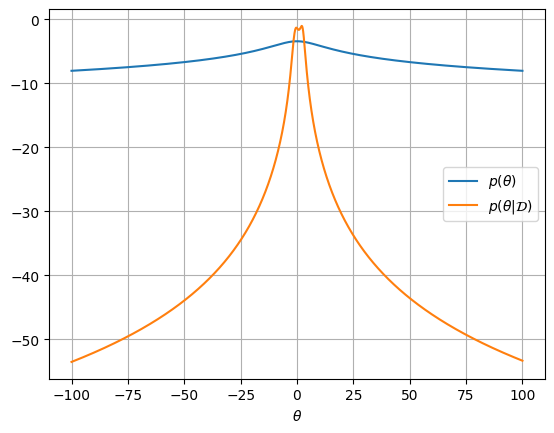

In [49]:
THETA = np.linspace(-100,100,10001)

plt.grid(True)
plt.plot(THETA,np.log(prior(THETA)),label=r'$p(\theta)$')
plt.plot(THETA,np.log(posterior(D,THETA)),label=r'$p(\theta|\mathcal{D})$')
plt.legend(); plt.xlabel(r'$\theta$'); plt.show()

### 结果解释

We observe that the posterior distribution is more concentrated to the specific values of the parameter that explain the dataset well. In particular, we observe the same two peaks around $\theta=-0.5$ and $\theta=2$ observed in the maximum likelihood exercise.

### Building a Classifier

We now would like to build a Bayes classifier based on the discriminant function

$$
h(x) = \log P(x|\mathcal{D}_1) -  \log P(x|\mathcal{D}_2) + \log P(\omega_1) - \log P(\omega_2)
$$

where the dataset-conditioned densities are obtained from the original data density model and the parameter posterior as

$$
p(x|\mathcal{D}_j) = \int p(x|\theta) p(\theta|\mathcal{D}_j) d\theta
$$

other formulas: 

for pdf:

$$
p(x|\theta) = \frac1\pi \frac{1}{1+(x-\theta)^2}
$$

for prior:

$$
p(\theta) = \frac{1}{10\pi} \frac{1}{1+(\theta/10)^2}
$$

for posterior:

$$
p(\theta | \mathcal{D}) = \frac{p(\mathcal{D} | \theta)p(\theta)}{\int p(\mathcal{D} | \theta)p(\theta) d\theta}
$$

Implement a function `fit` that produces the parameter posteriors $p(\theta|\mathcal{D}_1)$ and $p(\theta|\mathcal{D}_2)$.

Implement a function `predict` computing the new discriminant function $h$ based on the dataset-conditioned data densities.

In [98]:
def pdf(X,THETA):
    # input X:(N, 1), THETA:(1,M)
    # output p(X|θ): (N,M)

    return (1.0 / np.pi) * (1.0 / (1+(X-THETA)**2))

def prior(THETA):
    # input THETA:(M,)
    # output p(θ): (M, )

    p_theta = (1/(10*np.pi))*(1/(1+(THETA/10)**2))
    return p_theta


def posterior(D,THETA):
    # input D:(N, ), THETA:(M,)
    # output p(θ|D): (M, )

    p_theta = prior(THETA) #(M, )
    D = D[:,np.newaxis] # (N,1)
    THETA = THETA[np.newaxis, :] # (1,M)
    p_D_theta = np.sum(np.log(pdf(D,THETA)),axis=0) # (M，)
    log_upper = p_D_theta + np.log(p_theta) #(M, )
    upper = np.exp(log_upper)  # (M, )
    down = np.trapezoid(upper,THETA.flatten()) # scalar
    return upper/down  # (M, )
    
    

In [ ]:
class BayesClassifier:
    
    def fit(self,THETA,D1,D2):
        # fit() is to calculate posterior and save parameter
        self.theta = THETA
        # p(θ|D1)
        self.p_theta_d1 = posterior(D1,THETA)  #(M,)
        # p(θ|D2)
        self.p_theta_d2 = posterior(D2, THETA) #(M,)
        

        
    def predict(self,X,p1,p2):
        # p(θ|D1),p(θ|D2) we already know by fit()
        # we need to know p(x|θ) to calculate p(x|D1)，p(x|D2)
        # P(ω1) = p1
        X = X[:,np.newaxis]
        T = self.theta[np.newaxis, : ]

        # p(x|θ)
        P_x_theta = pdf(X,T) #(N,M)

        # p(x|D1)
        p_theta_d1 = self.p_theta_d1[np.newaxis,:] # (1,M)
        P_x_D1 = np.trapezoid(P_x_theta * p_theta_d1,self.theta,axis=1)

        # p(x|D2)
        p_theta_d2 = self.p_theta_d2[np.newaxis,:]
        P_x_D2 = np.trapezoid(P_x_theta*p_theta_d2,self.theta, axis=1)

        h = (
            np.log(P_x_D1) 
            - np.log(P_x_D2) 
            + np.log(p1) 
            - np.log(p2)
        )

        return h
   

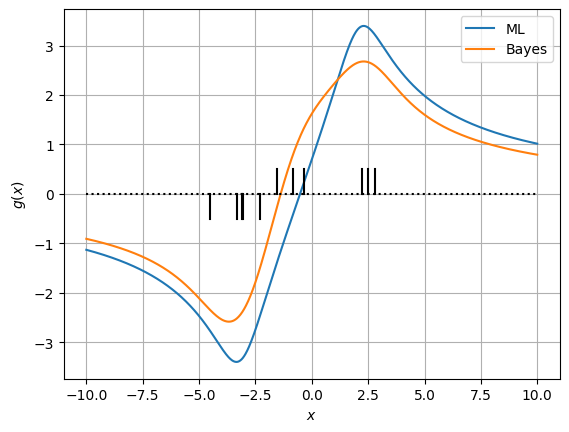

In [100]:
X = np.linspace(-10,10,1001)

bacl = BayesClassifier()
bacl.fit(THETA,D1,D2)

plt.grid(True)
plt.plot(X,mlcl.predict(X,0.5,0.5),label='ML')
plt.plot(X,bacl.predict(X,0.5,0.5),label='Bayes')

plt.plot(X,0*X,color='black',ls='dotted')
plt.xlabel(r'$x$'); plt.ylabel(r'$g(x)$')
plt.legend()

for d1 in D1: plt.plot([d1,d1],[0,+0.5],color='black')
for d2 in D2: plt.plot([d2,d2],[0,-0.5],color='black')

### 结果解释

We observe that the Bayes classifier has generally lower output scores and its decision boundary has been noticeably shifted to the left, leading to better predictions for the current data. In this particular case, the difference between the two models can be explained by the fact that the Bayes one better integrates the possibility that negative examples for the first class are not necessarily outliers.

# 3 PCA

In this exercise, we will experiment with two different techniques to compute the PCA components of a dataset:

* **Singular Value Decomposition (SVD)**

* **Power Iteration**: A technique that iteratively optimizes the PCA objective.

We consider a random subset of the Labeled Faces in the Wild (LFW) dataset, readily accessible from sklearn, and we apply some basic preprocessing to discount strong variations of luminosity and contrast.

D.shape: (样本数，高度，宽度)

下面的代码做了4件事：
- 加载人脸数据
- 随机采样 2000 张
- 每张图做 zero-mean
- 每张图做 unit-variance

In [7]:
# --------------------------------------------------
# 1. Load and preprocess data
# --------------------------------------------------
D = sklearn.datasets.fetch_lfw_people(resize=0.5)['images']
D = D[np.random.mtrand.RandomState(1).permutation(len(D))[:2000]]*1.0
D = D - D.mean(axis=(1,2),keepdims=True)
D = D / D.std(axis=(1,2),keepdims=True)
print(D.shape)

(2000, 62, 47)


Two functions are provided for your convenience and are available in `utils.py` that is included in the zip archive. The functions are the following:

* **`utils.scatterplot`** produces a scatter plot from a two-dimensional data set.

* **`utils.render`** takes an array of data points or objects of similar shape, and renders them in the IPython notebook.

Some demo code that makes use of these functions is given below.

In [5]:
# --------------------------------------------------
# 2. Helper functions
# --------------------------------------------------
def render(x,w,h,vmax=0.1):
    # 把多张图片拼接并可视化
    x = x.reshape([h,w,62,47])
    z = np.ones([h,w,64,49])*vmax
    z[:,:,1:-1,1:-1] = x
    x = z.reshape([h,w,64,49]).transpose([0,2,1,3]).reshape([h*64,w*49])
    plt.figure(figsize=(0.49*2*w,0.64*2*h))
    plt.imshow(x,cmap=plt.cm.gray,vmin=-vmax,vmax=vmax)
    plt.axis('off')
    plt.show()

def scatterplot(x,y,xlabel='',ylabel=''):
    # 分析像素之间的统计关系
    plt.figure(figsize=(3,3))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.plot(x,y,'.') 
    plt.show()

""" 
解析 scatterplot
plt.plot(x,y,'.') 画的是一个散点图，每一个点代表一张图片中的两个相邻像素值
即(xi​,yi​)=(pixel(32,20),pixel(32,21)))
本质目的检查 像素之间的相关性(correlation), 验证：相邻像素是不是独立的？
典型现象
如果点呈现斜线 → 强相关
如果点是圆形 → 弱相关
如果完全散乱 → 独立 

相邻像素通常 强相关
这个图通常用来说明“像素独立假设是不成立的”
"""

" \n解析 scatterplot\nplt.plot(x,y,'.') 画的是一个散点图，每一个点代表一张图片中的两个相邻像素值\n即(xi\u200b,yi\u200b)=(pixel(32,20),pixel(32,21)))\n本质目的检查 像素之间的相关性(correlation), 验证：相邻像素是不是独立的？\n典型现象\n如果点呈现斜线 → 强相关\n如果点是圆形 → 弱相关\n如果完全散乱 → 独立 \n\n相邻像素通常 强相关\n这个图通常用来说明“像素独立假设是不成立的”\n"

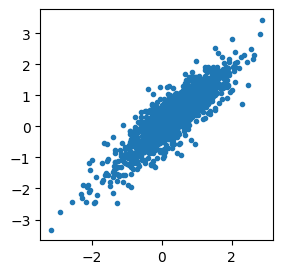

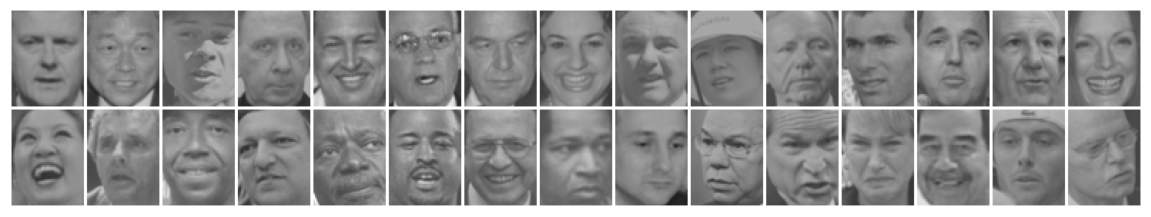

In [5]:
# D[:,32,20] → 所有图片在位置 (32,20) 的像素值 → shape (N,)
# D[:,32,21] → 所有图片在位置 (32,21) 的像素值 → shape (N,)

scatterplot(D[:,32,20],D[:,32,21]) # Plot relation between adjacent pixels
render(D[:30],15,2,vmax=5) 

### PCA with Singular Value Decomposition (15 P)

别方，数据clean一下，然后调用np.linalg.svd就行

Principal components can be found computing a singular value decomposition. Specifically, we assume a matrix $\bar{X}$ whose columns contain the data points represented as vectors, and where the data points have been centered (i.e. we have substracted to each of them the mean of the dataset). The matrix $\bar{X}$ is of size $d \times N$ where $d$ is the number of input features and $N$ is the number of data points. This matrix, more specifically, the rescaled matrix $Z = \frac{1}{\sqrt{N}} \bar{X}$ is then decomposed using singular value decomposition:
$$
\textstyle U \Lambda V = Z
$$
The $k$ principal components can then be found in the first $k$ columns of the matrix $U$.

**Tasks:**

* **Compute the principal components of the data using the function `numpy.linalg.svd`.**
* **Measure the computational time required to find the principal components. Use the function `time.time()` for that purpose. Do *not* include in your estimate the computation overhead caused by loading the data, plotting and rendering.**
* **Plot the projection of the dataset on the first two principal components using the function `utils.scatterplot`.**
* **Visualize the 60 leading principal components using the function `utils.render`.**

Note that if the algorithm runs for more than 3 minutes, there may be some error in your implementation.

X shape: (2000, 2914)
X_bar_cols shape: (2914, 2000)
U shape: (2914, 2000)
S shape: (2000,)
Vt shape: (2000, 2000)
SVD time: 3.2209300994873047 seconds
Y shape: (2, 2000)


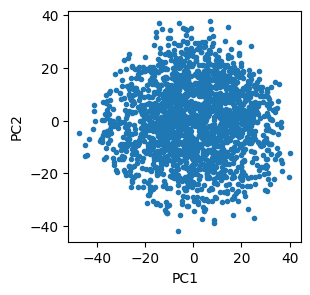

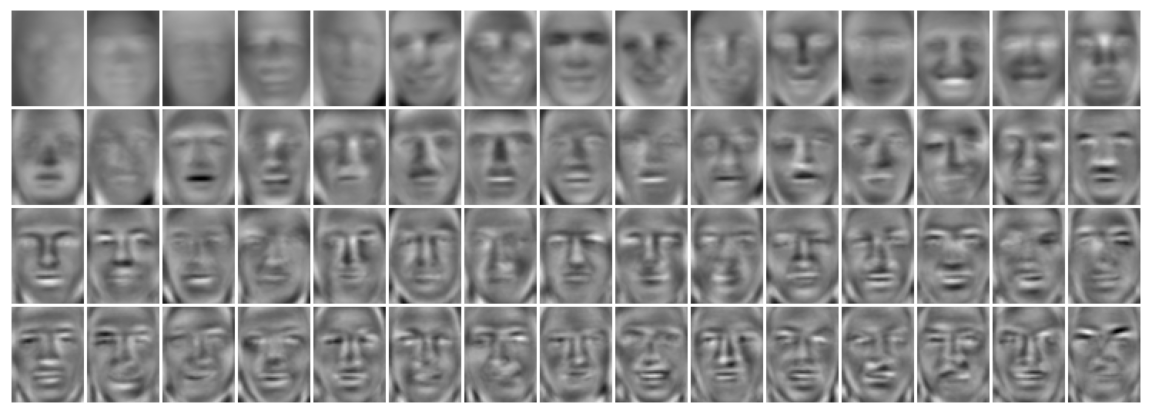

In [10]:

# --------------------------------------------------
# 1. Load and preprocess data
# --------------------------------------------------
D = sklearn.datasets.fetch_lfw_people(resize=0.5)['images']
D = D[np.random.mtrand.RandomState(1).permutation(len(D))[:2000]]*1.0
D = D - D.mean(axis=(1,2),keepdims=True)
D = D / D.std(axis=(1,2),keepdims=True)
# shape of D: (2000, 62, 47)

# --------------------------------------------------
# 2. Prepare data matrix for PCA
#    X: (N, d)
#    X_bar_cols: (d, N), each column = one centered sample
# --------------------------------------------------
N = D.shape[0]
X = D.reshape(N, -1)                        # (2000, 2914), 2914 = 62*47
mean_face = X.mean(axis=0, keepdims=True)   # (1, 2914)
X_centered = X - mean_face                  # (2000, 2914)
X_bar_cols = X_centered.T                   # (2914, 2000)

# --------------------------------------------------
# 3. Build Z = (1/sqrt(N)) * X_bar and compute SVD
# --------------------------------------------------
Z = X_bar_cols / np.sqrt(N)

t0 = time.time()
U, S, Vt = np.linalg.svd(Z, full_matrices=False)
t1 = time.time()

# --------------------------------------------------
# 4. First k principal components are in first k columns of U
# --------------------------------------------------
PCs = U

# --------------------------------------------------
# 5. Project dataset onto first two principal components
#    projection = U[:, :2]^T X_bar
# --------------------------------------------------
Y = PCs[:, :2].T @ X_bar_cols   # (2, 2914) @ (2914, 2000) = (2, 2000)


# --------------------------------------------------
# 6. Visualize the first 60 principal components and make scatter plot
# --------------------------------------------------
print("X shape:", X.shape)
print("X_bar_cols shape:", X_bar_cols.shape)
print("U shape:", U.shape)     # expected: (2914, 2000)
print("S shape:", S.shape)     # expected: (2000,)
print("Vt shape:", Vt.shape)   # expected: (2000, 2000)
print("SVD time:", t1 - t0, "seconds")
print("Y shape:", Y.shape)      # expected: (2, 2000)

scatterplot(Y[0], Y[1], xlabel='PC1', ylabel='PC2')
render(PCs[:, :60].T, 15, 4, vmax=0.1)


### PCA with Power Iteration (15 P)

The first PCA algorithm based on singular value decomposition is quite expensive to compute. Instead, the power iteration algorithm looks only for the first component and finds it using an iterative procedure. It starts with an initial weight vector $\boldsymbol{w} \in \mathbb{R}^d$, and repeatedly applies the update rule

$$
\boldsymbol{w} \leftarrow S \boldsymbol{w} \,\big/\, \|S \boldsymbol{w}\|.
$$

where $S$ is the covariance matrix defined as $S = \frac1N \bar{X}\bar{X}^\top$. Like for standard PCA, the objective that iterative PCA optimizes is $J(\boldsymbol{w}) = \boldsymbol{w}^\top S \boldsymbol{w}$ subject to the unit norm constraint for $\boldsymbol{w}$. We can therefore keep track of the progress of the algorithm after each iteration.

**Tasks:**

* **Implement the power iteration algorithm. Use as a stopping criterion the value of $J(\boldsymbol{w})$ between two iterations increasing by less than 0.01.**
* **Print the value of the objective function $J(\boldsymbol{w})$ at each iteration.**
* **Measure the time taken to find the principal component.**
* **Visualize the the eigenvector $\boldsymbol{w}$ obtained after convergence using the function `utils.render`.**

Note that if the algorithm runs for more than 1 minute, there may be some error in your implementation.

D shape: (2000, 62, 47)
X shape: (2000, 2914)
X_centered_cols shape: (2914, 2000)
S shape: (2914, 2914)
Iteration 1: J(w) = 210.005635
Iteration 2: J(w) = 257.221637
Iteration 3: J(w) = 262.903178
Iteration 4: J(w) = 264.755092
Iteration 5: J(w) = 265.577739
Iteration 6: J(w) = 265.980663
Iteration 7: J(w) = 266.188556
Iteration 8: J(w) = 266.299841
Iteration 9: J(w) = 266.361059
Iteration 10: J(w) = 266.395404
Iteration 11: J(w) = 266.414936
Iteration 12: J(w) = 266.426147
Iteration 13: J(w) = 266.432620
Converged after 13 iterations
Time taken: 0.3264012336730957 seconds


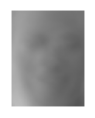

In [7]:
# --------------------------------------------------
# 1. Load and preprocess data
# --------------------------------------------------
D = sklearn.datasets.fetch_lfw_people(resize=0.5)['images']
D = D[np.random.mtrand.RandomState(1).permutation(len(D))[:2000]] * 1.0

# per-image normalization
D = D - D.mean(axis=(1, 2), keepdims=True)
D = D / D.std(axis=(1, 2), keepdims=True)

print("D shape:", D.shape)   # expected: (2000, 62, 47)

# --------------------------------------------------
# 2. Prepare centered data matrix
#    X_centered_cols shape: (d, N)
# --------------------------------------------------
N = D.shape[0]
X = D.reshape(N, -1)                         # (N, d)
mean_face = X.mean(axis=0, keepdims=True)   # (1, d)
X_centered = X - mean_face                  # (N, d)
X_centered_cols = X_centered.T              # (d, N)

d = X_centered_cols.shape[0]

print("X shape:", X.shape)
print("X_centered_cols shape:", X_centered_cols.shape)


# --------------------------------------------------
# 3. Covariance matrix S = (1/N) X_bar X_bar^T, 协方差，这是定义好的
# --------------------------------------------------
S = (X_centered_cols @ X_centered_cols.T) / N
print("S shape:", S.shape)


# --------------------------------------------------
# 4. Power iteration
#    stop when J(w) increases by less than 0.01
# --------------------------------------------------
rng = np.random.RandomState(0)
w = rng.randn(d)
w = w / np.linalg.norm(w)

prev_J = -np.inf
iteration = 0

t0 = time.time()

while True:
    iteration += 1

    # update
    Sw = S @ w
    w = Sw / np.linalg.norm(Sw)

    # objective J(w) = w^T S w, 这是定义好的
    J = w.T @ S @ w
    print(f"Iteration {iteration}: J(w) = {J:.6f}")

    # stopping criterion
    if J - prev_J < 0.01:
        break

    prev_J = J

t1 = time.time()

print("Converged after", iteration, "iterations")
print("Time taken:", t1 - t0, "seconds")


# --------------------------------------------------
# 6. Visualize the principal eigenvector
# --------------------------------------------------
render(w.reshape(1, -1), 1, 1, vmax=0.1)



# 4 Clustering

Weighted K-Means Clustering

In this exercise we will simulate finding good locations for production plants of a company in order to minimize its logistical costs. In particular, we would like to place production plants near customers so as to reduce shipping costs and delivery time.

We assume that the probability of someone being a customer is independent of its geographical location and that the overall cost of delivering products to customers is proportional to the squared Euclidean distance to the closest production plant. Under these assumptions, the K-Means algorithm is an appropriate method to find a good set of locations. Indeed, K-Means finds a spatial clustering of potential customers and the centroid of each cluster can be chosen to be the location of the plant.

Because there are potentially millions of customers, and that it is not scalable to model each customer as a data point in the K-Means procedure, we consider instead as many points as there are geographical locations, and assign to each geographical location a weight $w_i$ corresponding to the number of inhabitants at that location. The resulting problem becomes a weighted version of K-Means where we seek to minimize the objective:

$$
J(c_1,\dots,c_K) = \frac{\sum_{i} w_i \min_k ||x_i-c_k||^2}{\sum_{i} w_i},
$$

where $c_k$ is the $k$th centroid, and $w_i$ is the weight of each geographical coordinate $x_i$. In order to minimize this cost function, we iteratively perform the following EM computations:

* **Expectation step:** Compute the set of points associated to each centroid:
$$
\forall~1 \leq k \leq K: \quad \mathcal{C}(k) \leftarrow \Big\{ i ~:~ k = \mathrm{arg}\min_k \| x_i - c_k \|^2 \Big\}
$$


* **Minimization step:** Recompute the centroid as a the (weighted) mean of the associated data points:
$$
\forall~1 \leq k \leq K: \quad c_k \leftarrow \frac{\sum_{i \in \mathcal{C}(k)} w_i \cdot x_i}{\sum_{i \in \mathcal{C}(k)} w_i}
$$


until the objective $J(c_1,\dots,c_K)$ has converged.


Getting started

In this exercise we will use data from http://sedac.ciesin.columbia.edu/, that we store in the files `data.mat` as part of the zip archive. The data contains for each geographical coordinates (latitude and longitude), the number of inhabitants and the corresponding country. Several variables and methods are provided in the file `utils.py`:


*  **`utils.population`** A 2D array with the number of inhabitants at each latitude/longitude.


*  **`utils.plot(latitudes,longitudes)`** Plot a list of centroids given as geographical coordinates in overlay to the population density map.

The code below plots three factories (white squares) with geographical coordinates (60,80),
(60,90),(60,100) given as input.

### Clutering Utils

In [ ]:
# ----------------------------------------
# Create a matrix of population density 
# ----------------------------------------

data = scipy.io.loadmat('data.mat')

population = data['population']
countries  = data['countries']

# ----------------------------------------
# Size of the map
# ----------------------------------------
assert(population.shape[0]==countries.shape[0])
assert(population.shape[1]==countries.shape[1])

# ----------------------------------------
# Plots geographical locations on a map
#
# input:
# - an array of latitudes
# - an array of longitudes
#
# ----------------------------------------
def plot(latitudes,longitudes):
    plt.figure(figsize=(14,10))
    plt.imshow(population**.25,cmap='Blues')
    for a in set(list(countries.flatten())): plt.contour((countries==a)*1.0,colors='black',levels=[0.5])
    plt.plot(longitudes,latitudes,'o',ms=7,markeredgewidth=1,mfc='yellow',mec='black')
    plt.axis([0,population.shape[1],population.shape[0],0])

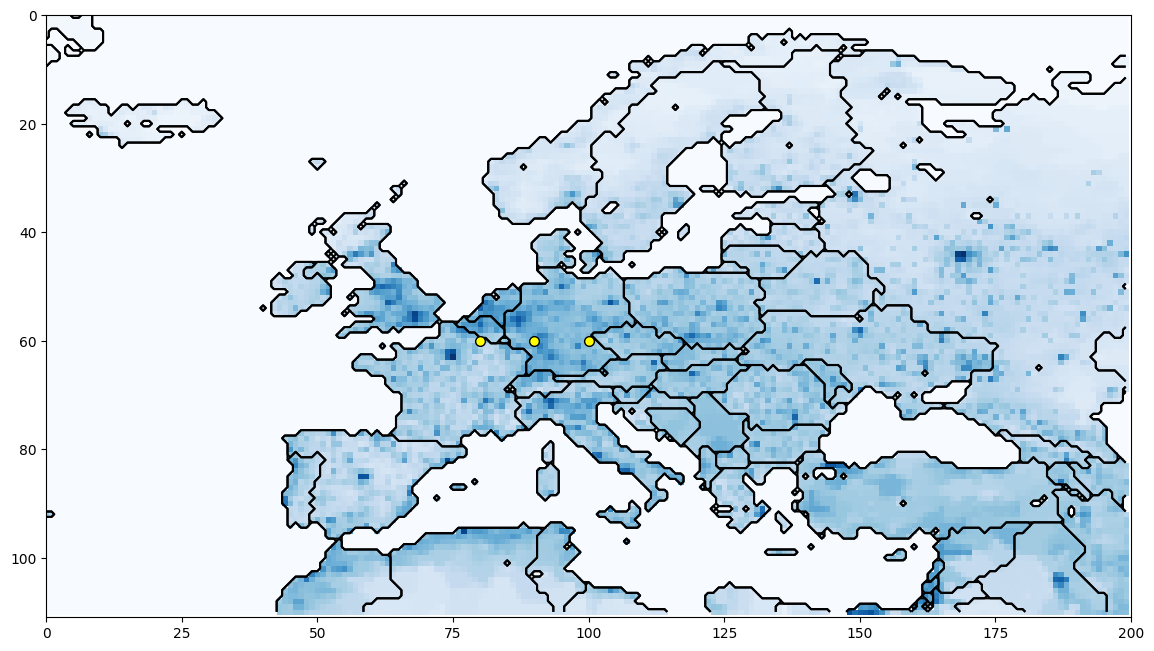

In [11]:
plot([60,60,60],[80,90,100])

In [12]:
# Also, to get a dataset of geographical coordinates 
# associated to the image given as an array, we can use:
x,y = numpy.indices(population.shape)
locations = numpy.array([x.flatten(),y.flatten()]).T

### Initializing Weighted K-Means

Because K-means has a non-convex objective, choosing a good initial set of centroids is important. Centroids are drawn from from the following discrete probability distribution:

$$
P(x,y) = \frac1Z \cdot \text{population}(x,y)
$$

where $Z$ is a normalization constant. Furthermore, to avoid identical centroids, we add a small Gaussian noise to the location of centroids, with standard deviation $0.01$.

In [ ]:
def initialize(K,population):
    # YOUR CODE HERE
    import solutions
    centroids = solutions.initialize(K, population)
    return centroids
    # --------------

In [13]:
def initialize(K, population):
    h, w = population.shape
    
    coords = np.indices((h, w)).reshape(2, -1).T
    weights = population.flatten().astype(float)
    
    prob = weights / weights.sum()
    
    indices = np.random.choice(len(coords), size=K, p=prob)
    centroids = coords[indices]
    
    centroids = centroids + np.random.normal(0, 0.01, centroids.shape)
    
    return centroids

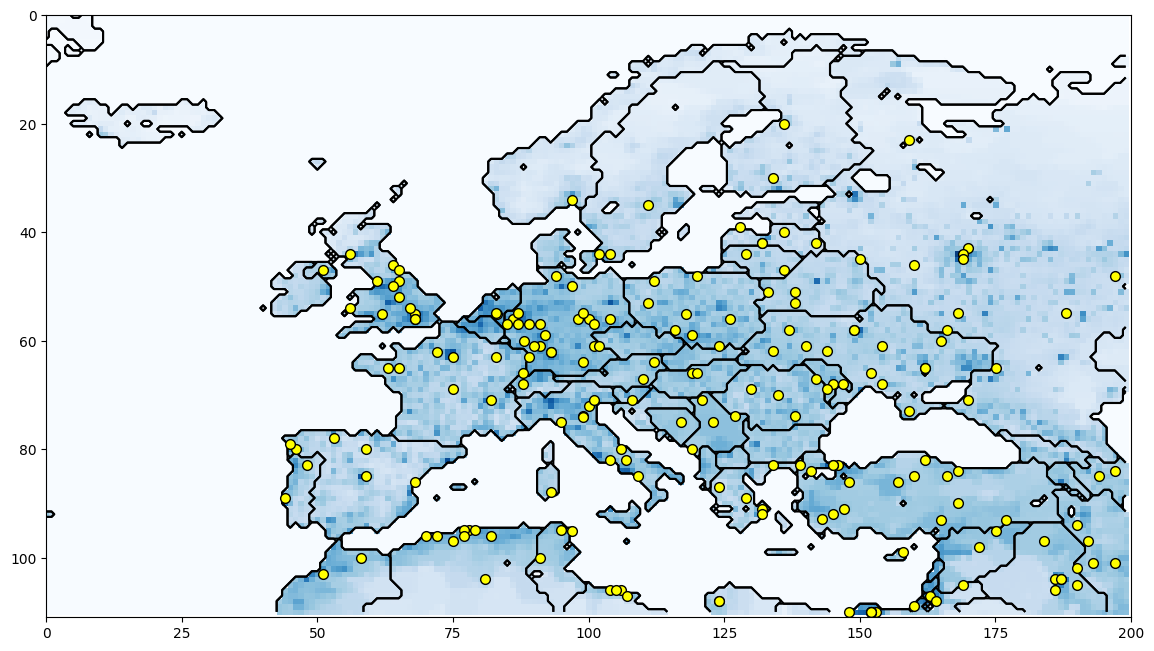

In [15]:
# The following code runs the initialization procedure 
# for K=200 clusters and visualizes the centroids 
# obtained with the initialization procedure using `utils.plot`.
centroids_init = initialize(200, population)
plot(centroids_init[:,0], centroids_init[:,1])

### Implementing Weighted K-Means 

* **Implement the weighted K-Means algorithm. Your algorithm should run for `nbit` iterations and print the value of the objective after training. If `verbose`, it should also print the value of the objective at each iteration.**

In [ ]:
def wkmeans(centroids, points, weights, verbose, nbit):
    # YOUR CODE HERE
    import solutions
    centroids = solutions.wkmeans(centroids, points, weights, verbose, nbit)
    return centroids
    # --------------

In [16]:
def wkmeans(centroids, points, weights, verbose=False, nbit=100):
    """
    Weighted K-Means

    Parameters
    ----------
    centroids : array of shape (K, 2)
        Initial centroids.
    points : array of shape (N, 2)
        Data points, each row is one geographical coordinate (x_i).
    weights : array of shape (N,)
        Weight of each point, e.g. population at that coordinate.
    verbose : bool
        If True, print objective at each iteration.
    nbit : int
        Number of iterations.

    Returns
    -------
    centroids : array of shape (K, 2)
        Final centroids.
    """
    
    centroids = np.asarray(centroids, dtype=float).copy()
    points = np.asarray(points, dtype=float)
    weights = np.asarray(weights, dtype=float)

    K = centroids.shape[0]
    total_weight = weights.sum()

    for it in range(nbit):
        # ----------------------------------------
        # E-step: assign each point to closest centroid
        # ----------------------------------------
        # distances shape: (N, K)
        distances = np.sum((points[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
        labels = np.argmin(distances, axis=1)

        # ----------------------------------------
        # M-step: recompute centroids as weighted means
        # ----------------------------------------
        new_centroids = centroids.copy()

        for k in range(K):
            mask = (labels == k)

            # if a cluster is empty, keep previous centroid
            if np.any(mask):
                cluster_points = points[mask]          # shape: (Nk, 2)
                cluster_weights = weights[mask]        # shape: (Nk,)

                new_centroids[k] = (
                    np.sum(cluster_weights[:, None] * cluster_points, axis=0)
                    / np.sum(cluster_weights)
                )

        centroids = new_centroids

        # ----------------------------------------
        # Compute objective
        # J = sum_i w_i * min_k ||x_i-c_k||^2 / sum_i w_i
        # ----------------------------------------
        distances = np.sum((points[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
        min_distances = np.min(distances, axis=1)
        objective = np.sum(weights * min_distances) / total_weight

        if verbose:
            print(f"iteration {it+1}/{nbit}: J = {objective:.6f}")

    print(f"Final objective: J = {objective:.6f}")
    return centroids

iteration 1/50: J = 11.417000
iteration 2/50: J = 10.061129
iteration 3/50: J = 9.503869
iteration 4/50: J = 9.260945
iteration 5/50: J = 9.024433
iteration 6/50: J = 8.804599
iteration 7/50: J = 8.646874
iteration 8/50: J = 8.541112
iteration 9/50: J = 8.451211
iteration 10/50: J = 8.362815
iteration 11/50: J = 8.216357
iteration 12/50: J = 8.120500
iteration 13/50: J = 8.058421
iteration 14/50: J = 8.036685
iteration 15/50: J = 8.024205
iteration 16/50: J = 8.014188
iteration 17/50: J = 8.009994
iteration 18/50: J = 8.007496
iteration 19/50: J = 8.006212
iteration 20/50: J = 8.005675
iteration 21/50: J = 8.003794
iteration 22/50: J = 8.001935
iteration 23/50: J = 8.001035
iteration 24/50: J = 7.999202
iteration 25/50: J = 7.996382
iteration 26/50: J = 7.993490
iteration 27/50: J = 7.992000
iteration 28/50: J = 7.991151
iteration 29/50: J = 7.990993
iteration 30/50: J = 7.990949
iteration 31/50: J = 7.990875
iteration 32/50: J = 7.990709
iteration 33/50: J = 7.990432
iteration 34/50: 

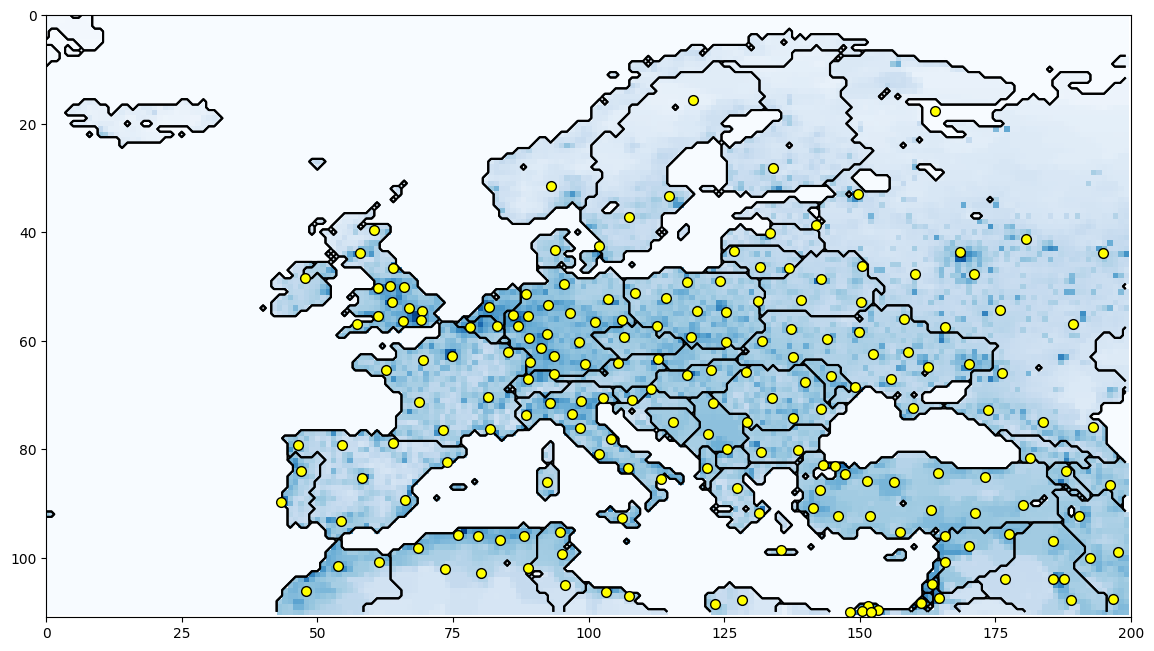

In [17]:
# The following code runs the weighted k-means 
# on this data, and displays the final centroids.

weights   = population.flatten()*1.0

centroids = wkmeans(centroids_init, locations, weights, True, 50)

plot(centroids[:,0], centroids[:,1])

In [18]:
# Observe that the k-means algorithm is non-convex, 
# and arrives in local optima of different quality 
# depending on the initialization:
for i in range(5):
    wkmeans(initialize(200, population), 
            locations, weights, False, 50)

Final objective: J = 7.854733
Final objective: J = 6.900534
Final objective: J = 7.170393
Final objective: J = 8.101903


/var/folders/kw/qrl_mkc50r98y8l95mp8w2g00000gn/T/ipykernel_43235/2067904688.py:53: RuntimeWarning: invalid value encountered in divide
  np.sum(cluster_weights[:, None] * cluster_points, axis=0)


Final objective: J = 7.330049


# 5 Fisher Discriminant

在高维空间中，如何找到一个“最有区分能力的投影方向”


In this exercise, we apply Fisher Linear Discriminant as described in Chapter 3.8.2 of Duda et al. on the UCI Abalone dataset. A description of the dataset is given at the page https://archive.ics.uci.edu/ml/datasets/Abalone. The following two methods are provided for your convenience: 


* **`utils.Abalone.__init__(self)`** reads the Abalone data and instantiates two data matrices corresponding to: *infant (I)*, *non-infant (N)*.


* **`utils.Abalone.plot(self,w)`** produces a histogram of the data when projected onto a vector `w`, and where each class is shown in a different color.


Sample code that makes use of these two methods is given below. It loads the data, looks at the shape of instantiated matrices, and plots the projection on the first dimension of the data representing the length of the abalone.

### fisher utils

In [6]:
class Abalone:

    # Instantiate the Abalone dataset
    #
    # input: None
    # output: None
    #
    def __init__(self):
        X = numpy.genfromtxt('abalone.csv',delimiter=',')
        self.N = X[X[:,0] <2][:,1:-1]
        self.I = X[X[:,0]==2][:,1:-1]

    # Plot a histogram of the projected data
    #
    # input: the projection vector and the name of the projection
    # output: None
    #
    def plot(self,w,name):
        plt.figure(figsize=(6,2))
        plt.xlabel(name)
        plt.ylabel('# examples')
        plt.hist(numpy.dot(self.I,w),bins=25, alpha=0.8,color='red',label='infant')
        plt.hist(numpy.dot(self.N,w),bins=25, alpha=0.8,color='gray',label='noninfant')
        plt.legend()
        plt.show()

### implementation

* **Create a function `w = fisher(X1,X2)` that takes as input the data for two classes and returns the Fisher linear discriminant.**


* **Create a function `objective(X1,X2,w)` that evaluates the objective defined in Equation 96 of Duda et al. for an arbitrary projection vector `w`.**


* **Create a function `z = phi(X)` that returns a quadratic expansion for each data point `x` in the dataset. Such expansion consists of the vector `x` itself, to which we concatenate the vector of all pairwise products between elements of `x`.** In other words, letting $x = (x_1,\dots,x_d)$ denote the $d$-dimensional data point, the quadratic expansion for this data point is a $d \cdot (d+3)/2$ dimensional vector given by $\phi(x) = (x_i)_{1 \leq i \leq d} \cup (x_i x_j)_{1 \leq i \leq j \leq d}$. For example, the quadratic expansion for $d=2$ is $(x_1,x_2,x_1^2,x_2^2,x_1 x_2)$.

(1342, 7) (2835, 7)


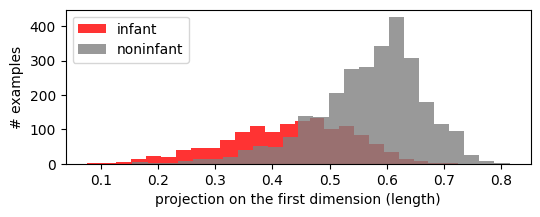

In [7]:
# Load the data
abalone = Abalone()

# Print dataset size for each class
print(abalone.I.shape, abalone.N.shape)

# Project data on the first dimension
w1 = numpy.array([1,0,0,0,0,0,0])
abalone.plot(w1,'projection on the first dimension (length)')

In [8]:
def fisher(X1,X2):
    ##### Replace by your code
    import solutions
    return solutions.fisher(X1,X2)
    #####
    
def objective(X1,X2,w):
    ##### Replace by your code
    import solutions
    return solutions.objective(X1,X2,w)
    #####
    
def expand(X):
    ##### Replace by your code
    import solutions
    return solutions.expand(X)
    #####

In [9]:
def fisher(X1, X2):
    import numpy as np
    
    m1 = np.mean(X1, axis=0)
    m2 = np.mean(X2, axis=0)
    
    X1c = X1 - m1
    X2c = X2 - m2
    
    S1 = X1c.T @ X1c
    S2 = X2c.T @ X2c
    SW = S1 + S2
    
    w = np.linalg.solve(SW, m1 - m2)
    return w


def objective(X1, X2, w):
    import numpy as np
    
    m1 = np.mean(X1, axis=0)
    m2 = np.mean(X2, axis=0)
    
    X1c = X1 - m1
    X2c = X2 - m2
    
    S1 = X1c.T @ X1c
    S2 = X2c.T @ X2c
    SW = S1 + S2
    
    num = (w.T @ (m1 - m2)) ** 2
    den = w.T @ SW @ w
    
    return num / den


def expand(X):
    import numpy as np
    
    n, d = X.shape
    features = [X]
    
    quad_terms = []
    for i in range(d):
        for j in range(i, d):
            quad_terms.append((X[:, i] * X[:, j])[:, None])
    
    quad_terms = np.hstack(quad_terms)
    
    Z = np.hstack([X, quad_terms])
    return Z

### analysis

* **Print value of the objective function and the histogram for several values of `w`:**

  * `w` is a canonical coordinate vector for the first feature (length).
  * `w` is the difference between the mean vectors of the two classes.
  * `w` is the Fisher linear discriminant.
  * `w` is the Fisher linear discriminant (after quadratic expansion of the data).

In [10]:
X1 = abalone.I
X2 = abalone.N

Case 1: first feature
objective = 0.0004797957500328474


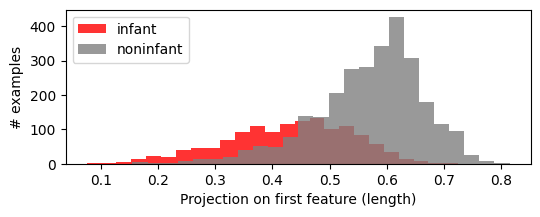

In [12]:
# Case 1：第一维（length）
# 只看一个原始特征，没有任何优化。
w1 = np.zeros(X1.shape[1])
w1[0] = 1.0

print("Case 1: first feature")
print("objective =", objective(X1, X2, w1))

abalone.plot(w1, 'Projection on first feature (length)')


Case 2: mean difference
objective = 0.000499575351975072


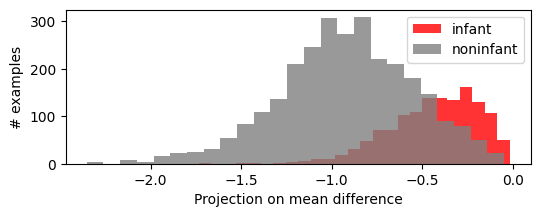

In [13]:
# Case 2：均值差方向
# 只考虑“类间距离”，不考虑类内散度
m1 = np.mean(X1, axis=0)
m2 = np.mean(X2, axis=0)

w_mean = m1 - m2

print("\nCase 2: mean difference")
print("objective =", objective(X1, X2, w_mean))

abalone.plot(w_mean, 'Projection on mean difference')


Case 3: Fisher LDA
objective = 0.0005691815990406675


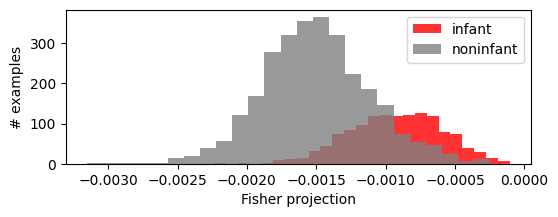

In [14]:
# Case 3：Fisher LDA
# 最优线性方向（理论上最大化 objective）
w_fisher = fisher(X1, X2)

print("\nCase 3: Fisher LDA")
print("objective =", objective(X1, X2, w_fisher))

abalone.plot(w_fisher, 'Fisher projection')


Case 4: Fisher with quadratic expansion
objective = 0.0007660025003508769


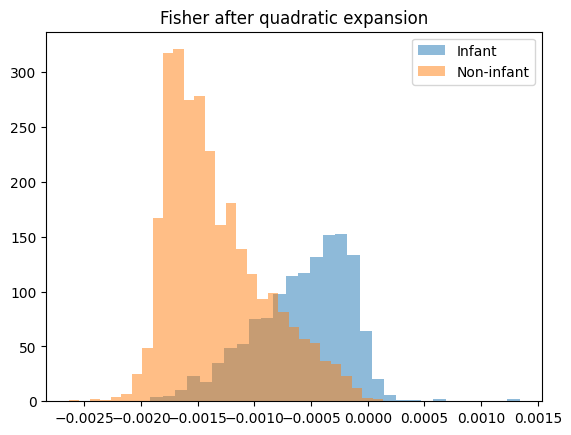

In [15]:
# Case 4：Quadratic expansion + Fisher
# 先做特征映射
Z1 = expand(X1)
Z2 = expand(X2)

# 再做 Fisher
w_quad = fisher(Z1, Z2)

print("\nCase 4: Fisher with quadratic expansion")
print("objective =", objective(Z1, Z2, w_quad))

# 手动画 histogram（因为维度不一样）
proj_I = Z1 @ w_quad
proj_N = Z2 @ w_quad

plt.hist(proj_I, bins=30, alpha=0.5, label='Infant')
plt.hist(proj_N, bins=30, alpha=0.5, label='Non-infant')
plt.legend()
plt.title('Fisher after quadratic expansion')
plt.show()

### 结果解释

Analysis of Different Projection Vectors

- Case 1: Projection on First Feature (Length)

The projection on the first feature (length) yields a relatively low objective value. The histograms of the two classes show significant overlap, indicating that a single feature is not sufficient to separate the classes effectively. This suggests that the discriminative information is distributed across multiple dimensions.

---

- Case 2: Projection on Mean Difference

Using the difference between the class means as the projection vector improves the separation compared to the first feature. The objective value increases, and the overlap between the two classes is reduced. However, this approach only considers the distance between class centers and ignores the spread (variance) within each class, which limits its effectiveness.

---

- Case 3: Fisher Linear Discriminant

The Fisher Linear Discriminant achieves a significantly higher objective value. The projected histograms show much better separation between the two classes. This is because Fisher’s method explicitly maximizes the ratio of between-class variance to within-class variance:

$
J(w) = \frac{(w^T (m_1 - m_2))^2}{w^T S_W w}
$

This leads to an optimal linear projection for class discrimination.

---

- Case 4: Fisher Discriminant after Quadratic Expansion

After applying quadratic feature expansion, the Fisher discriminant yields the highest objective value among all cases. The separation between the two classes improves further, often showing minimal overlap.

This indicates that the data is not linearly separable in the original feature space, but becomes more separable in a higher-dimensional space. The quadratic expansion allows the model to capture nonlinear relationships, effectively resulting in a nonlinear decision boundary in the original space.

---

- Summary

Overall, the results demonstrate that:

- Simple projections (e.g., single feature) are insufficient for classification.
- Considering class means improves separation but is still limited.
- Fisher Linear Discriminant provides an optimal linear solution.
- Feature expansion enables nonlinear separability and further improves performance.

This highlights the importance of both choosing an appropriate objective function and using expressive feature representations.

不同投影方向的分析

- 情况 1：投影到第一维（Length）

将数据投影到第一个特征（length）时，objective 值相对较低。从直方图可以看到两类数据存在明显重叠，说明仅使用单一特征无法有效区分类别。这表明判别信息分布在多个特征维度中，而不是集中在某一个特征上。

---

- 情况 2：使用均值差作为投影方向

使用两类均值向量之差作为投影方向，相比第一种方法，分类效果有所改善。objective 值有所提高，两类之间的重叠减少。然而，该方法只考虑了类间距离（between-class distance），忽略了类内方差（within-class variance），因此仍然不是最优的判别方向。

---

- 情况 3：Fisher 线性判别（Fisher LDA）

Fisher 判别方法取得了明显更高的 objective 值。投影后的直方图显示两类数据的分离更加清晰。这是因为 Fisher 方法最大化了类间方差与类内方差之比：

$
J(w) = \frac{(w^T (m_1 - m_2))^2}{w^T S_W w}
$

因此，它能够找到最优的线性投影方向，使类别之间的可分性最大。

---

- 情况 4：二次特征展开 + Fisher 判别

在对数据进行二次特征展开之后，Fisher 判别取得了最高的 objective 值。此时两类数据的分布进一步分离，重叠显著减少，甚至可能接近完全分开。

这说明原始特征空间中的数据并不是线性可分的，而通过映射到更高维空间后，数据变得更加可分。二次特征展开相当于在原空间中引入了非线性决策边界，从而提升了分类性能。

---

- 总结

整体来看：

- 单一特征的投影无法有效分类；
- 使用均值差可以一定程度改善结果，但仍不充分；
- Fisher 线性判别提供了最优的线性分类方向；
- 特征展开（如二次扩展）可以引入非线性能力，从而进一步提高分类效果。

这说明，在分类问题中，**合理的目标函数 + 更有表达能力的特征空间** 是提升模型性能的关键。

# 6 Regression

### regression util

In [23]:
def gaussianKernel(X1,X2,width):
    """
    Generates the Gaussian kernel matrix K with K[i,j]=k(X1[i,:],X2[j,:])
    """
    return numpy.exp(-scipy.spatial.distance.cdist(X1,X2,metric='sqeuclidean')/(2*width**2))


def split(X,Y):
    """
    Partitions a dataset into a training and test set
    """
    n=len(X)

    rstate = numpy.random.mtrand.RandomState(2345)

    R = rstate.permutation(n)
    Rtrain = R[:n//2]
    Rtest  = R[n//2:]

    Xtrain = X[Rtrain] # Training data
    Ytrain = Y[Rtrain] # Training targets

    Xtest  = X[Rtest] # Test data
    Ytest  = Y[Rtest] # Test targets

    return Xtrain,Ytrain,Xtest,Ytest



def toy():
    """
    Simple One-Dimensional Dataset
    """

    # number of examples
    n = 40

    # function parameters
    a      = 1
    b      = 2.65
    offset = 1
    noise  = 0.2

    rstate = numpy.random.mtrand.RandomState(12345)

    X = rstate.uniform(-3,3,[n,1])

    Y1 = numpy.sin(a*X)+numpy.cos(b*X+offset)
    Y2 = 0.5*numpy.cos(2*b*X-offset)+0.3*numpy.sin(0.1*a*X-2)
    Y3 = rstate.normal(0,noise,X.shape)

    Y = (Y1+Y2+Y3).flatten()

    return X,Y


def yacht():
    """
    Yacht Hydrodynamics Data Set
    """

    D = numpy.loadtxt(open("yacht_hydrodynamics.csv","rb"),delimiter=",",skiprows=1)

    X,Y = D[:,:-1],D[:,-1]

    return X,Y


### Gaussian Processes


In this exercise, you will implement Gaussian process regression and apply it to a toy and a real dataset. We use the notation used in the paper "Rasmussen (2005). Gaussian Processes in Machine Learning" linked on ISIS.

Let us first draw a training set $X = (x_1,\dots,x_n)$ and a test set $X_\star = (x^\star_1,\dots,x^\star_m)$ from a $d$-dimensional input distribution. The Gaussian Process is a model under which the real-valued outputs $\mathbf{f} = (f_1,\dots,f_n)$ and $\mathbf{f}_\star = (f^\star_1,\dots,f^\star_m)$ associated to $X$ and $X_\star$ follow the Gaussian distribution:

\begin{equation*}
\left[
\begin{array}{c}\mathbf{f}\\
\mathbf{f}_\star\end{array}
\right]
\sim
\mathcal{N}
\left(
\left[
\begin{array}{c}
\boldsymbol{0}\\
\boldsymbol{0}
\end{array}
\right]
,
\left[
\begin{array}{cc}
\Sigma & \Sigma_\star\\
\Sigma_\star^\top & \Sigma_{\star\star}
\end{array}
\right]
\right)
\end{equation*}

where

\begin{align*}
\Sigma &= k(X,X)+\sigma^2 I\\
\Sigma_\star &= k(X,X_\star)\\
\Sigma_{\star\star} &= k(X_\star,X_\star)+\sigma^2 I
\end{align*}

and where $k(\cdot,\cdot)$ is the Gaussian kernel function. (The kernel function is implemented in `utils.py`.) Predicting the output for new data points $X_\star$ is achieved by conditioning the joint probability distribution on the training set. Such conditional distribution called posterior distribution can be written as:

\begin{equation}
\mathbf{f}_\star | \mathbf{f} \sim \mathcal{N} (
\underbrace{\Sigma_\star^\top \Sigma^{-1} \mathbf{f}}_{\boldsymbol{\mu}_\star}
~,~
\underbrace{\Sigma_{\star\star} - \Sigma_\star^\top \Sigma^{-1} \Sigma_\star}_{C_\star}
)
\end{equation}

Having inferred the posterior distribution, the log-likelihood of observing for the inputs $X_\star$ the outputs $\mathbf{y}_\star$ is given by evaluating the distribution $\mathbf{f}_\star | \mathbf{f}$ at $\mathbf{y}_\star$:

\begin{equation}
\log p(\mathbf{y}_\star | \mathbf{f}) = -\frac1{2} (\mathbf{y}_\star - \boldsymbol{\mu}_\star)^\top C^{-1}_\star (\mathbf{y}_\star - \boldsymbol{\mu}_\star) - \frac1{2}\log|C_\star| - \frac{m}{2}\log2\pi
\end{equation}

where $|\cdot|$ is the determinant. Note that the likelihood of the data given this posterior distribution can be measured both for the training data and the test data.

**Tasks:**

* **Create a class `GP_Regressor` that implements a Gaussian process regressor and has the following three methods:**

 * **`def __init__(self,Xtrain,Ytrain,width,noise):`** Initialize a Gaussian process with noise parameter $\sigma$ and width parameter $w$. The variable `Xtrain` is a two-dimensional array where each row is one data point from the training set. The Variable `Ytrain` is a vector containing the associated targets. The function must also precompute the matrix $\Sigma^{-1}$ for subsequent use by the method `predict()` and `loglikelihood()`.

 * **`def predict(self,Xtest):`** For the test set $X_\star$ of $m$ points received as parameter, return the mean vector of size $m$ and covariance matrix of size $m \times m$ of the corresponding output, that is, return the parameters $(\boldsymbol{\mu}_\star,C_\star)$ of the Gaussian distribution $\mathbf{f}_\star | \mathbf{f}$.

 * **`def loglikelihood(self,Xtest,Ytest):`** For a data set $X_\star$ of $m$ test points received as first parameter, return the loglikelihood of observing the outputs $\mathbf{y}_\star$ received as second parameter.

In [ ]:
# --------------------------
# TODO: Replace by your code
# --------------------------
import solutions
class GP_Regressor(solutions.GP_Regressor):
    pass
# --------------------------

In [20]:
class GP_Regressor:
    
    def __init__(self, Xtrain, Ytrain, width, noise):
        """
        Xtrain: shape (n, d)
        Ytrain: shape (n,)
        width : Gaussian kernel width
        noise : noise standard deviation sigma
        """
        self.Xtrain = Xtrain
        self.Ytrain = Ytrain
        self.width = width
        self.noise = noise
        
        n = Xtrain.shape[0]
        
        # Sigma = k(X,X) + sigma^2 I
        self.Sigma = gaussianKernel(Xtrain, Xtrain, width) + (noise ** 2) * numpy.eye(n)
        
        # Precompute Sigma^{-1}
        self.Sigma_inv = numpy.linalg.inv(self.Sigma)
    
    def predict(self, Xtest):
        """
        Xtest: shape (m, d)
        
        Returns:
            mean: shape (m,)
            cov : shape (m, m)
        """
        m = Xtest.shape[0]
        
        # Sigma_* = k(X, X_*)
        Sigma_star = gaussianKernel(self.Xtrain, Xtest, self.width)   # (n, m)
        
        # Sigma_** = k(X_*, X_*) + sigma^2 I
        Sigma_starstar = gaussianKernel(Xtest, Xtest, self.width) + (self.noise ** 2) * numpy.eye(m)
        
        # mu_* = Sigma_*^T Sigma^{-1} y
        mean = Sigma_star.T @ self.Sigma_inv @ self.Ytrain
        
        # C_* = Sigma_** - Sigma_*^T Sigma^{-1} Sigma_*
        cov = Sigma_starstar - Sigma_star.T @ self.Sigma_inv @ Sigma_star
        
        return mean, cov
    
    def loglikelihood(self, Xtest, Ytest):
        """
        Xtest: shape (m, d)
        Ytest: shape (m,)
        
        Returns:
            scalar log-likelihood
        """
        mean, cov = self.predict(Xtest)
        m = Xtest.shape[0]
        
        diff = Ytest - mean
        
        cov_inv = numpy.linalg.inv(cov)
        sign, logdet = numpy.linalg.slogdet(cov)
        
        ll = -0.5 * diff.T @ cov_inv @ diff \
             -0.5 * logdet \
             -0.5 * m * numpy.log(2 * numpy.pi)
        
        return ll

* **Test your implementation by running the code below (it visualizes the mean and variance of the prediction at every location of the input space) and compares the behavior of the Gaussian process for various noise parameters $\sigma$ and width parameters $w$.**

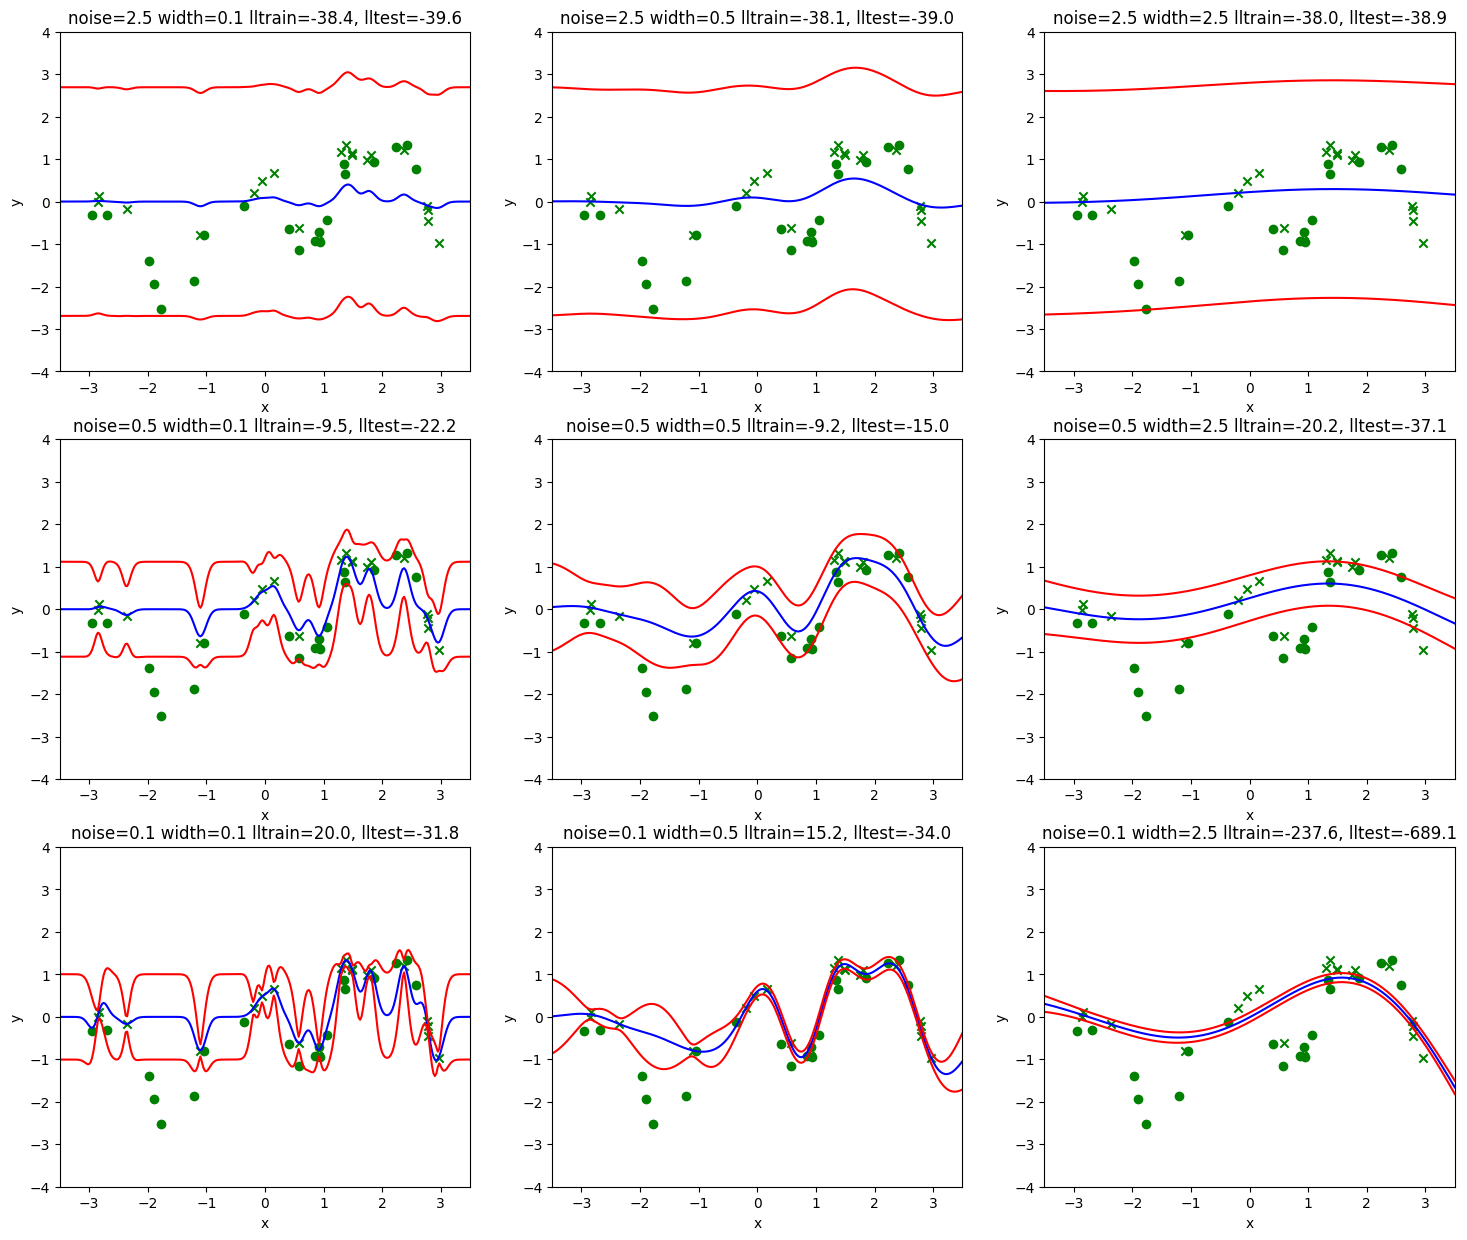

In [21]:

# Open the toy data
Xtrain,Ytrain,Xtest,Ytest = split(*toy())

# Create an analysis distribution
Xrange = numpy.arange(-3.5,3.51,0.025)[:,numpy.newaxis]

f = plt.figure(figsize=(18,15))

# Loop over several parameters:
for i,noise in enumerate([2.5,0.5,0.1]):
    for j,width in enumerate([0.1,0.5,2.5]):

        # Create Gaussian process regressor object
        gp = GP_Regressor(Xtrain,Ytrain,width,noise)
        
        # Compute the predicted mean and variance for test data
        mean,cov = gp.predict(Xrange)
        var = cov.diagonal()
        
        # Compute the log-likelihood of training and test data
        lltrain = gp.loglikelihood(Xtrain,Ytrain)
        lltest  = gp.loglikelihood(Xtest ,Ytest )
     
        # Plot the data
        p = f.add_subplot(3,3,3*i+j+1)
        p.set_title('noise=%.1f width=%.1f lltrain=%.1f, lltest=%.1f'%(noise,width,lltrain,lltest))
        p.set_xlabel('x')
        p.set_ylabel('y')
        p.scatter(Xtrain,Ytrain,color='green',marker='x') # training data
        p.scatter(Xtest,Ytest,color='green',marker='o')   # test data
        p.plot(Xrange,mean,color='blue')                  # GP mean
        p.plot(Xrange,mean+var**.5,color='red')           # GP mean + std
        p.plot(Xrange,mean-var**.5,color='red')           # GP mean - std
        p.set_xlim(-3.5,3.5)
        p.set_ylim(-4,4)

### application to the yacht hydrodynamics data set

In the second part, we would like to apply the Gaussian process regressor that you have implemented to a real dataset: the Yacht Hydrodynamics Data Set available on the UCI repository at the webpage http://archive.ics.uci.edu/ml/datasets/Yacht+Hydrodynamics. As stated on the web page, the input variables for this regression problem are:

1. Longitudinal position of the center of buoyancy
2. Prismatic coefficient
3. Length-displacement ratio
4. Beam-draught ratio
5. Length-beam ratio
6. Froude number

and we would like to predict from these variables the residuary resistance per unit weight of displacement (last column in the file `yacht_hydrodynamics.data`).

**Tasks:**

* **Load the data using `datasets.yacht()` and partition the data between training and test set using the function `utils.split()`. Standardize the data (center and rescale) so that each dimension of the training data and the labels have mean 0 and standard deviation 1 over the training set.**


* **Train several Gaussian processes on the regression task using various combinations of width and noise parameters.**


* **Draw two contour plots where the training and test log-likelihood are plotted as a function of the noise and width parameters. Choose suitable ranges of parameters so that the best parameter combination for the test set is in the plot. Use the same ranges and contour levels for the training and test plots. The contour levels can be chosen linearly spaced between e.g. 50 and the maximum log-likelihood value**

In [24]:

# --------------------------------------------------
# 1. Load and split data
# --------------------------------------------------
X, Y = yacht()
Xtrain, Ytrain, Xtest, Ytest = split(X, Y)

# --------------------------------------------------
# 2. Standardize using training-set statistics
# --------------------------------------------------
X_mean = Xtrain.mean(axis=0)          # shape (d,)
X_std  = Xtrain.std(axis=0)           # shape (d,)

Y_mean = Ytrain.mean()                # scalar
Y_std  = Ytrain.std()                 # scalar

# avoid division by zero, just in case
X_std = numpy.where(X_std == 0, 1, X_std)
if Y_std == 0:
    Y_std = 1

Xtrain_std = (Xtrain - X_mean) / X_std
Xtest_std  = (Xtest  - X_mean) / X_std

Ytrain_std = (Ytrain - Y_mean) / Y_std
Ytest_std  = (Ytest  - Y_mean) / Y_std

print("Xtrain_std mean:", Xtrain_std.mean(axis=0))
print("Xtrain_std std :", Xtrain_std.std(axis=0))
print("Ytrain_std mean:", Ytrain_std.mean())
print("Ytrain_std std :", Ytrain_std.std())

Xtrain_std mean: [ 1.40047741e-15  2.54115447e-14  2.11737853e-14 -3.56314470e-15
  1.89746548e-14 -2.81546754e-16]
Xtrain_std std : [1. 1. 1. 1. 1. 1.]
Ytrain_std mean: -5.805087710458335e-17
Ytrain_std std : 1.0


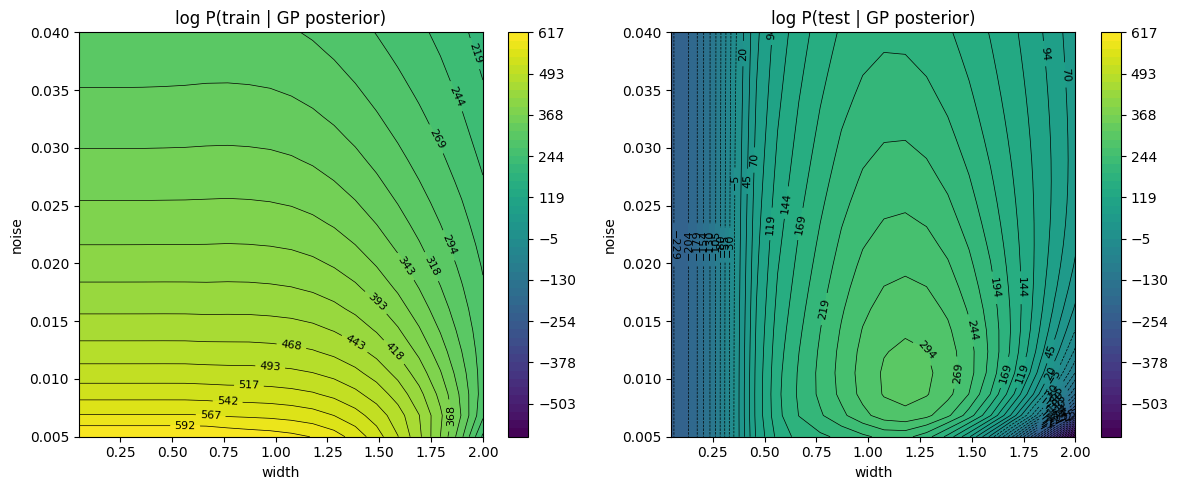

Noise params: 0.005 0.007 0.008 0.010 0.011 0.013 0.014 0.016 0.017 0.019 0.020 0.022 0.023 0.025 0.026 0.028 0.029 0.031 0.032 0.034 0.035 0.037 0.038 0.040
Width params: 0.050 0.135 0.220 0.304 0.389 0.474 0.559 0.643 0.728 0.813 0.898 0.983 1.067 1.152 1.237 1.322 1.407 1.491 1.576 1.661 1.746 1.830 1.915 2.000


In [30]:
# --------------------------------------------------
# 1) Load & split
# --------------------------------------------------
X, Y = yacht()
Xtrain, Ytrain, Xtest, Ytest = split(X, Y)

# --------------------------------------------------
# 2) Standardize (using training stats only)
# --------------------------------------------------
X_mean = Xtrain.mean(axis=0)
X_std  = Xtrain.std(axis=0)
X_std  = numpy.where(X_std == 0, 1, X_std)

Y_mean = Ytrain.mean()
Y_std  = Ytrain.std() if Ytrain.std() != 0 else 1

Xtrain_std = (Xtrain - X_mean) / X_std
Xtest_std  = (Xtest  - X_mean) / X_std

Ytrain_std = (Ytrain - Y_mean) / Y_std
Ytest_std  = (Ytest  - Y_mean) / Y_std

# --------------------------------------------------
# 3) Linear parameter grid (关键：不是 logspace)
# --------------------------------------------------
width_values = numpy.linspace(0.05, 2.0, 20)
noise_values = numpy.linspace(0.005, 0.04, 20)

LLtrain = numpy.zeros((len(noise_values), len(width_values)))
LLtest  = numpy.zeros((len(noise_values), len(width_values)))

# --------------------------------------------------
# 4) Grid search
# --------------------------------------------------
for i, noise in enumerate(noise_values):
    for j, width in enumerate(width_values):
        gp = GP_Regressor(Xtrain_std, Ytrain_std, width, noise)
        LLtrain[i, j] = gp.loglikelihood(Xtrain_std, Ytrain_std)
        LLtest[i, j]  = gp.loglikelihood(Xtest_std,  Ytest_std)

# --------------------------------------------------
# 5) Contour plots (老师风格)
# --------------------------------------------------
W, N = numpy.meshgrid(width_values, noise_values)

# 同一套 levels（关键）
vmin = min(LLtrain.min(), LLtest.min())
vmax = max(LLtrain.max(), LLtest.max())
levels = numpy.linspace(vmin, vmax, 50)

plt.figure(figsize=(12,5))

# --- Train ---
plt.subplot(1,2,1)
cf1 = plt.contourf(W, N, LLtrain, levels=levels, cmap='viridis')
c1  = plt.contour(W, N, LLtrain, levels=levels, colors='black', linewidths=0.5)
plt.clabel(c1, inline=True, fontsize=8)

plt.xlabel('width')
plt.ylabel('noise')
plt.title('log P(train | GP posterior)')
plt.colorbar(cf1)

# --- Test ---
plt.subplot(1,2,2)
cf2 = plt.contourf(W, N, LLtest, levels=levels, cmap='viridis')
c2  = plt.contour(W, N, LLtest, levels=levels, colors='black', linewidths=0.5)
plt.clabel(c2, inline=True, fontsize=8)

plt.xlabel('width')
plt.ylabel('noise')
plt.title('log P(test | GP posterior)')
plt.colorbar(cf2)

plt.tight_layout()
plt.show()

# 参数（和老师一致）
width_values = numpy.linspace(0.05, 2.0, 24)
noise_values = numpy.linspace(0.005, 0.04, 24)

# 格式化打印（关键）
print("Noise params:", " ".join(f"{n:.3f}" for n in noise_values))
print("Width params:", " ".join(f"{w:.3f}" for w in width_values))

# 7 SVM

# 8 Model Selection

# 9 Neural Network

# 10 Decision Tree